# What this notebook is doing (temperature variable checks)

This notebook is mostly a temperature workbench for checking what variables are actually available in the different datasets and whether they behave the way I expect.
I used it to test online sources, local sources, and different temperature workflows before folding the cleaner pieces into the later notebooks.

The early cells are mainly variable-availability and quality checks for sources like ERA5, CONUS404, and SNOTEL.
Later cells move into water-year mean temperature comparisons across datasets like Daymet, UCLA ERA5 d02, HRRR, PNNL, and others, including some trial versions and fixes.

So this is not one polished final analysis notebook.
It is more of a troubleshooting and development notebook for temperature variables, units, and dataset comparison logic.


In [1]:
# ==========================================================
# CHECK TEMPERATURE VARIABLE AVAILABILITY (ONLINE SOURCES)
# ERA5 (ARCO GCS) + CONUS404 (HyTEST) + SNOTEL (egagli repo)
# ==========================================================

import xarray as xr
import intake
import pandas as pd

print("\n================ ERA5 (ARCO GCS) ================")
try:
    ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
    ds_era5 = xr.open_zarr(
        ERA5_STORE,
        consolidated=False,
        storage_options={"token": "anon"},
        chunks={}
    )
    vars_era5 = list(ds_era5.data_vars)
    print("Available variables:", vars_era5[:20], "..." if len(vars_era5) > 20 else "")
    if "t2m" in vars_era5:
        print(" ERA5 temperature available: 't2m'")
    else:
        print(" ERA5 temperature variable 't2m' NOT found")
    ds_era5.close()
except Exception as e:
    print("ERA5 check failed:", e)


print("\n================ CONUS404 (HyTEST) ================")
try:
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds_conus = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    vars_conus = list(ds_conus.data_vars)
    print("Available variables:", vars_conus)

    temp_candidates = ["T2", "T2MEAN", "T2D", "T2m", "air_temperature"]
    found = [v for v in temp_candidates if v in vars_conus]

    if found:
        print(f" CONUS404 temperature variable(s) found: {found}")
    else:
        print(" No obvious temperature variable found in CONUS404 dataset")
except Exception as e:
    print("CONUS404 check failed:", e)


print("\n================ SNOTEL (egagli repo) ================")
try:
    test_station = "991_WA_SNTL"  # example station
    url = f"https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{test_station}.csv"
    df = pd.read_csv(url)

    print("Available columns:", list(df.columns))

    temp_candidates = ["TAVG", "TMAX", "TMIN", "TOBS", "TMEAN", "TEMP", "air_temperature"]
    found = [c for c in temp_candidates if c in df.columns]

    if found:
        print(f" SNOTEL temperature column(s) found: {found}")
    else:
        print(" No obvious temperature column found in SNOTEL CSV")
except Exception as e:
    print("SNOTEL check failed:", e)



================ ERA5 (ARCO GCS) ================
Available variables: ['100m_u_component_of_wind', '10m_wind_gust_since_previous_post_processing', '10m_v_component_of_wind', 'anisotropy_of_sub_gridscale_orography', '2m_dewpoint_temperature', 'benjamin_feir_index', 'boundary_layer_dissipation', '100m_v_component_of_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind', 'charnock', '10m_u_component_of_neutral_wind', 'cloud_base_height', 'clear_sky_direct_solar_radiation_at_surface', 'convective_precipitation', 'convective_available_potential_energy', 'convective_snowfall', 'boundary_layer_height', 'coefficient_of_drag_with_waves', 'downward_uv_radiation_at_the_surface'] ...
 ERA5 temperature variable 't2m' NOT found

================ CONUS404 (HyTEST) ================
Available variables: ['ACDEWC', 'ACDRIPR', 'ACDRIPS', 'ACECAN', 'ACEDIR', 'ACETLSM', 'ACETRAN', 'ACEVAC', 'ACEVB', 'ACEVC', 'ACEVG', 'ACFROC', 'ACFRZC', 'ACGHB', 'ACGHFLSM', 'ACGHV', 'ACINTR', 'ACINTS', 'ACL

In [2]:
# ERA5: search for temp-like variables (name contains "2m" and "temperature")
temp_vars = [v for v in vars_era5 if ("2m" in v and "temperature" in v) or (v.endswith("temperature") and "2m" in v)]
print(temp_vars)

['2m_dewpoint_temperature', '2m_temperature', 'maximum_2m_temperature_since_previous_post_processing', 'minimum_2m_temperature_since_previous_post_processing']


In [3]:
print([v for v in vars_era5 if "temperature" in v][:60])


['2m_dewpoint_temperature', '2m_temperature', 'ice_temperature_layer_1', 'ice_temperature_layer_2', 'ice_temperature_layer_4', 'lake_bottom_temperature', 'ice_temperature_layer_3', 'lake_mix_layer_temperature', 'lake_ice_temperature', 'lake_total_layer_temperature', 'maximum_2m_temperature_since_previous_post_processing', 'minimum_2m_temperature_since_previous_post_processing', 'soil_temperature_level_2', 'soil_temperature_level_3', 'sea_surface_temperature', 'soil_temperature_level_1', 'skin_temperature', 'soil_temperature_level_4', 'temperature', 'temperature_of_snow_layer', 'vertical_integral_of_temperature']


In [4]:
import requests, pandas as pd

base = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
for code in ["991_WA_SNTL", "630_WA_SNTL", "515_WA_SNTL", "672_WA_SNTL"]:
    url = f"{base}/{code}.csv"
    try:
        df = pd.read_csv(url, nrows=5)
        print(" works:", code, "cols:", list(df.columns))
        break
    except Exception as e:
        print(" fail:", code, e)


 fail: 991_WA_SNTL HTTP Error 404: Not Found
 fail: 630_WA_SNTL HTTP Error 404: Not Found
 works: 515_WA_SNTL cols: ['datetime', 'TAVG', 'TMIN', 'TMAX', 'SNWD', 'WTEQ', 'PRCPSA']


In [6]:
# ==========================================================
# TEMPERATURE DATA QUALITY CHECK (NETWORK-SAFE)
# ERA5: 2m_temperature
# CONUS404: T2
# Includes: units, range, dt, missing, "cumulative?" sanity check
# ==========================================================

import time, random
import numpy as np
import pandas as pd
import xarray as xr
import intake
import zarr
import dask

# ---- Make remote reads less flaky ----
zarr.config.set({"async.concurrency": 1})     # key fix for OSN/S3 payload errors
dask.config.set(scheduler="threads")         # avoid async scheduler surprises

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

def median_dt_hours(time_values):
    t = pd.to_datetime(time_values)
    if len(t) < 2:
        return np.nan
    dt = np.diff(t.values).astype("timedelta64[s]").astype(np.int64)
    return float(np.median(dt) / 3600.0)

def load_with_retries(expr, tries=8, base_sleep=0.6):
    last = None
    for i in range(tries):
        try:
            return expr.compute()
        except Exception as e:
            last = e
            sleep = base_sleep * (2 ** i) + random.random() * 0.25
            print(f"  [retry {i+1}/{tries}] {type(e).__name__}: {e}  -> sleep {sleep:.2f}s")
            time.sleep(sleep)
    raise last

def monotonic_increasing_fraction(x):
    x = np.asarray(x).astype("float64")
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    dif = np.diff(x)
    return float((dif >= 0).mean())

# ==========================================================
# ERA5
# ==========================================================
print("\n================ ERA5 (ARCO) ================")
ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds_era5 = xr.open_zarr(
    ERA5_STORE,
    consolidated=False,
    storage_options={"token": "anon"},
    chunks={"time": 24 * 7}
)

v_era5 = "2m_temperature"
t2m = ds_era5[v_era5].sel(time=slice(GLOBAL_START, GLOBAL_END))

print("var:", v_era5)
print("units attr:", t2m.attrs.get("units"))
print("dims:", t2m.dims, "shape:", tuple(t2m.sizes[d] for d in t2m.dims))
print("median dt (hours):", median_dt_hours(t2m.time.values))

# tiny sample: 200 timesteps at one grid point
# (works even if lat/lon dims are named latitude/longitude)
lat_dim = "latitude" if "latitude" in t2m.dims else ("lat" if "lat" in t2m.dims else None)
lon_dim = "longitude" if "longitude" in t2m.dims else ("lon" if "lon" in t2m.dims else None)

sample_era5 = t2m.isel(time=slice(0, 200))
if lat_dim and lon_dim:
    sample_era5 = sample_era5.isel({lat_dim: 10, lon_dim: 10})

sample_era5 = load_with_retries(sample_era5)

vals = sample_era5.values
print("min/max/mean:", float(np.nanmin(vals)), float(np.nanmax(vals)), float(np.nanmean(vals)))
print("missing frac:", float(np.isnan(vals).mean()))
print("monotonic-increasing frac (should NOT be ~1.0):", monotonic_increasing_fraction(vals))

ds_era5.close()

# ==========================================================
# CONUS404
# ==========================================================
print("\n================ CONUS404 (HyTEST daily-osn) ================")
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds_conus = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

v_conus = "T2"
t2 = ds_conus[v_conus].sel(time=slice(GLOBAL_START, GLOBAL_END))

print("var:", v_conus)
print("units attr:", t2.attrs.get("units"))
print("dims:", t2.dims, "shape:", tuple(t2.sizes[d] for d in t2.dims))
print("median dt (hours):", median_dt_hours(t2.time.values))

# tiny sample: 200 timesteps at one grid point
# (CONUS404 typically uses y/x)
sample_conus = t2.isel(time=slice(0, 200))

# choose dims robustly
for d in ("y", "south_north"):
    if d in sample_conus.dims:
        sample_conus = sample_conus.isel({d: 50})
        break
for d in ("x", "west_east"):
    if d in sample_conus.dims:
        sample_conus = sample_conus.isel({d: 50})
        break

sample_conus = load_with_retries(sample_conus)

vals2 = sample_conus.values
print("min/max/mean:", float(np.nanmin(vals2)), float(np.nanmax(vals2)), float(np.nanmean(vals2)))
print("missing frac:", float(np.isnan(vals2).mean()))
print("monotonic-increasing frac (should NOT be ~1.0):", monotonic_increasing_fraction(vals2))


================ ERA5 (ARCO) ================
var: 2m_temperature
units attr: K
dims: ('time', 'latitude', 'longitude') shape: (61368, 721, 1440)
median dt (hours): 1.0
min/max/mean: 259.1048889160156 269.4698486328125 262.9315490722656
missing frac: 0.0
monotonic-increasing frac (should NOT be ~1.0): 0.3417085427135678

================ CONUS404 (HyTEST daily-osn) ================
var: T2
units attr: K
dims: ('time', 'y', 'x') shape: (2557, 1015, 1367)
median dt (hours): 24.0
min/max/mean: 292.6775207519531 298.0492858886719 294.7772216796875
missing frac: 0.0
monotonic-increasing frac (should NOT be ~1.0): 0.49246231155778897


In [7]:
# ==========================================================
# WATER YEAR MEAN TEMPERATURE (°C)
# ERA5 + CONUS404 + SNOTEL
# WY2014–WY2020
# ==========================================================

import xarray as xr
import pandas as pd
import numpy as np
import intake
import geopandas as gpd
import regionmask
import shapely.geometry as sgeom
import requests
import zarr, dask

# ---- Stabilize remote reads ----
zarr.config.set({"async.concurrency": 1})
dask.config.set(scheduler="threads")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10,
                    time_da.dt.year + 1,
                    time_da.dt.year)

def water_year_mean(da):
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group":"year"})
    return out

def to_celsius(da):
    return da - 273.15 if float(da.mean()) > 150 else da

# ---------------- LOAD REGIONS ----------------
BOUNDARY_GEO = "../data/GIS/SkagitBoundary.json"
HUC8_GEO     = "../data/GIS/SkagitSubBasin_HUC8.geojson"
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
huc8_3 = gpd.overlay(huc8[huc8["Name"].isin(REGION_NAMES)], skagit, how="intersection")

regions = regionmask.Regions(
    outlines=list(huc8_3.geometry),
    names=list(huc8_3["Name"]),
    numbers=list(range(len(huc8_3))),
)

rows = []

# ==========================================================
# ERA5 (Hourly → Daily → WY Mean)
# ==========================================================
print("Processing ERA5...")

ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds_era5 = xr.open_zarr(
    ERA5_STORE,
    consolidated=False,
    storage_options={"token": "anon"},
    chunks={"time": 24*7}
)

if float(ds_era5.longitude.min()) >= 0:
    ds_era5 = ds_era5.assign_coords(
        longitude=((ds_era5.longitude + 180) % 360) - 180
    ).sortby("longitude")

lat_slice = slice(49.8,48.0) if ds_era5.latitude[0] > ds_era5.latitude[-1] else slice(48.0,49.8)
lon_slice = slice(-123.4,-120.2)

t2m = ds_era5["2m_temperature"].sel(
    time=slice(GLOBAL_START, GLOBAL_END),
    latitude=lat_slice,
    longitude=lon_slice
)

t2m = to_celsius(t2m)
t_daily = t2m.resample(time="1D").mean()

lon2d, lat2d = xr.broadcast(
    ds_era5.longitude.sel(longitude=lon_slice),
    ds_era5.latitude.sel(latitude=lat_slice)
)
mask = regions.mask(lon2d, lat2d)

wy_mean = water_year_mean(t_daily)

for wy in range(YEAR_MIN, YEAR_MAX+1):
    for i, rname in enumerate(regions.names):
        val = wy_mean.sel(year=wy).where(mask==i).mean().compute()
        rows.append({
            "dataset":"ERA5",
            "region":rname,
            "year":wy,
            "temp_c":float(val)
        })

ds_era5.close()

# ==========================================================
# CONUS404 (Daily → WY Mean)
# ==========================================================
print("Processing CONUS404...")

url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds_conus = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

t2 = ds_conus["T2"].sel(time=slice(GLOBAL_START, GLOBAL_END))
t2 = to_celsius(t2)

mask_conus = regions.mask(ds_conus["lon"], ds_conus["lat"])
wy_mean2 = water_year_mean(t2)

for wy in range(YEAR_MIN, YEAR_MAX+1):
    for i, rname in enumerate(regions.names):
        val = wy_mean2.sel(year=wy).where(mask_conus==i).mean().compute()
        rows.append({
            "dataset":"CONUS404",
            "region":rname,
            "year":wy,
            "temp_c":float(val)
        })

# ==========================================================
# SNOTEL (Mean of Stations)
# ==========================================================
print("Processing SNOTEL...")

stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
r = requests.get(stations_url)
gj = r.json()

records, geoms = [], []
for feat in gj["features"]:
    records.append(feat["properties"])
    geoms.append(sgeom.shape(feat["geometry"]))

stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
skagit_stations = stations[stations.geometry.within(skagit.geometry.iloc[0])]

base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

station_wy = {}

for _, row in skagit_stations.iterrows():
    code = row["code"]
    try:
        df_s = pd.read_csv(f"{base_csv_url}/{code}.csv", parse_dates=["datetime"])
    except:
        continue

    if "TAVG" not in df_s.columns:
        continue

    temp = df_s.set_index("datetime")["TAVG"]
    temp = temp.loc[GLOBAL_START:GLOBAL_END]

    wy_idx = np.where(temp.index.month>=10,
                      temp.index.year+1,
                      temp.index.year)

    annual = pd.DataFrame({"temp":temp.values,"wy":wy_idx}).groupby("wy")["temp"].mean()

    for wy,val in annual.items():
        if YEAR_MIN<=wy<=YEAR_MAX:
            station_wy.setdefault(wy,[]).append(val)

for wy,vals in station_wy.items():
    rows.append({
        "dataset":"SNOTEL (mean stations)",
        "region":"All Stations",
        "year":wy,
        "temp_c":float(np.nanmean(vals))
    })

# ==========================================================
# OUTPUT
# ==========================================================
df = pd.DataFrame(rows).sort_values(["region","dataset","year"])
print("\nWY Mean Temperature (°C), 2014–2020:\n")
print(df)


Processing ERA5...
Processing CONUS404...
Processing SNOTEL...

WY Mean Temperature (°C), 2014–2020:

                   dataset        region  year     temp_c
42  SNOTEL (mean stations)  All Stations  2014   5.339126
43  SNOTEL (mean stations)  All Stations  2015   5.835303
44  SNOTEL (mean stations)  All Stations  2016   4.977851
45  SNOTEL (mean stations)  All Stations  2017   4.060548
46  SNOTEL (mean stations)  All Stations  2018   4.343663
47  SNOTEL (mean stations)  All Stations  2019   4.232211
48  SNOTEL (mean stations)  All Stations  2020   3.653809
23                CONUS404  Lower Skagit  2014   9.104556
26                CONUS404  Lower Skagit  2015  10.484637
29                CONUS404  Lower Skagit  2016   9.883896
32                CONUS404  Lower Skagit  2017   8.916159
35                CONUS404  Lower Skagit  2018   9.184841
38                CONUS404  Lower Skagit  2019   9.238587
41                CONUS404  Lower Skagit  2020   8.932790
2                     ERA5  

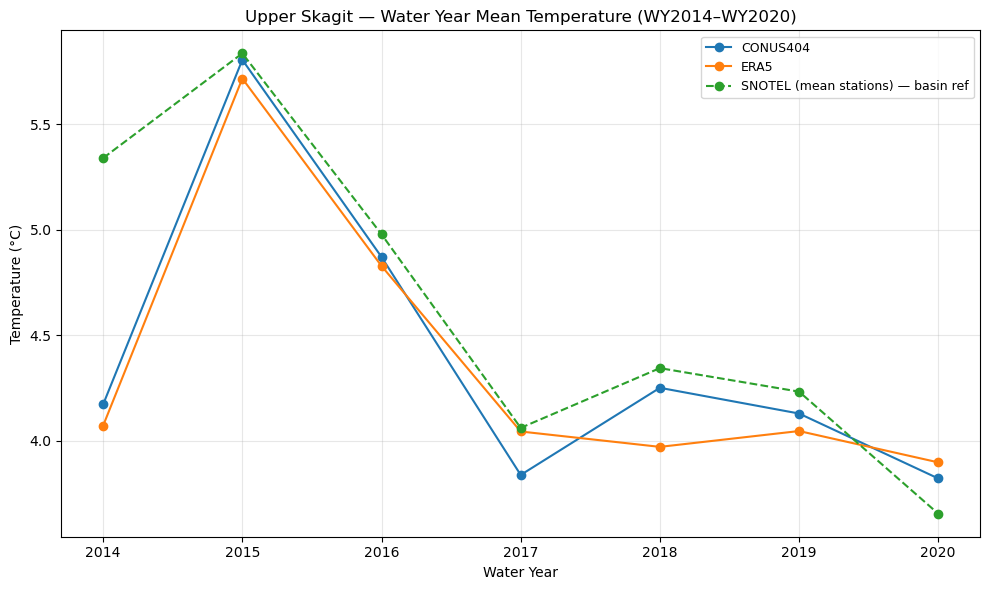

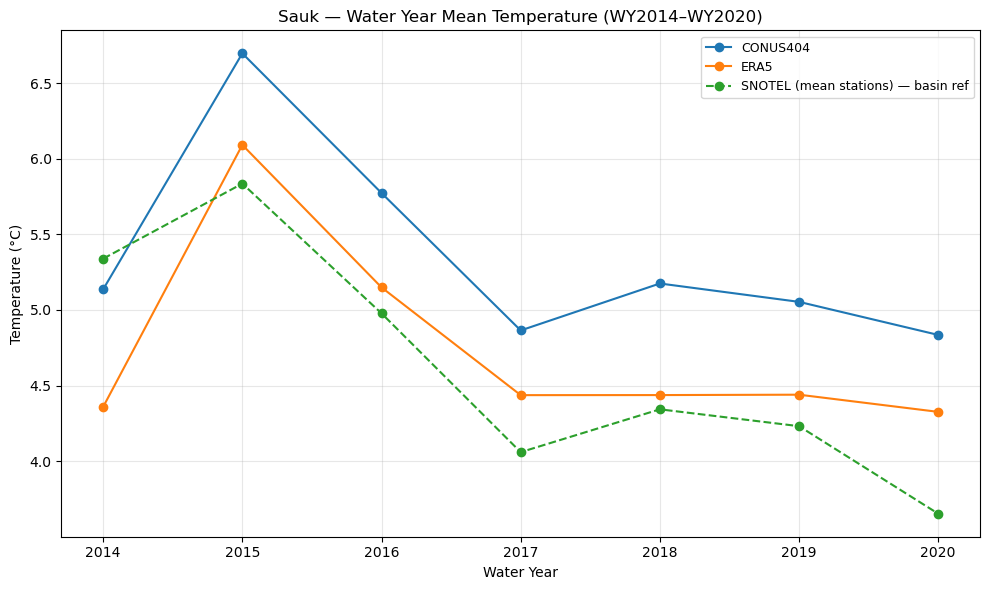

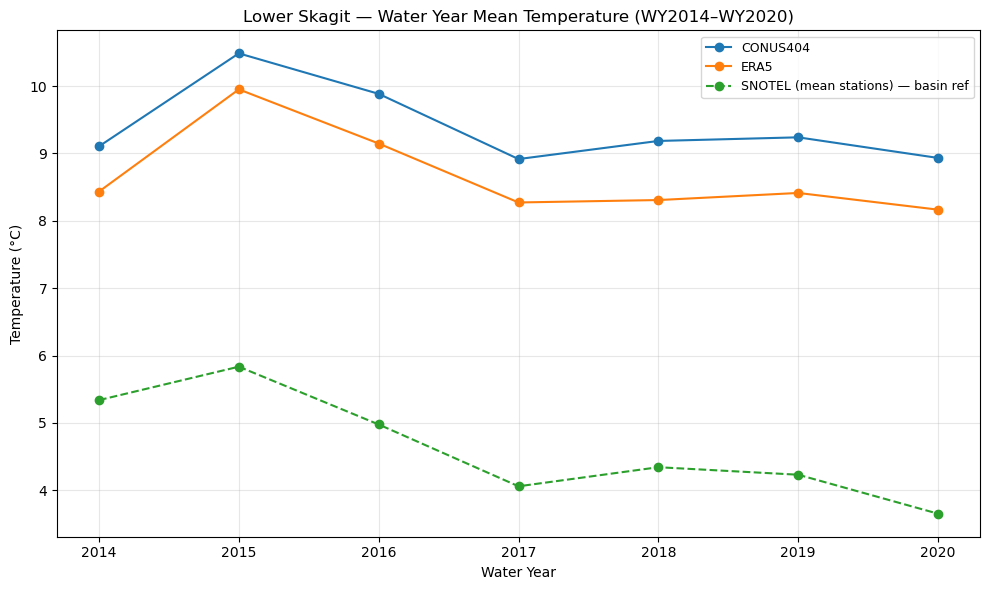

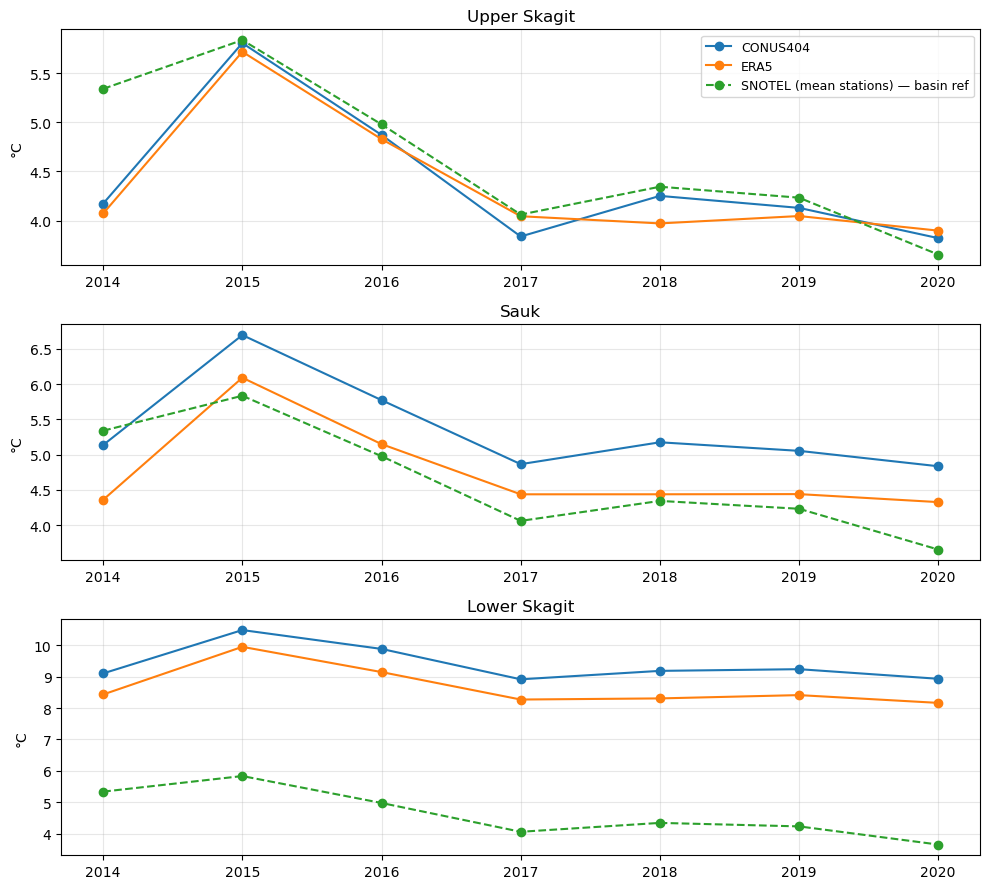

In [9]:
import matplotlib.pyplot as plt
import numpy as np

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Pull SNOTEL series once
snotel = df[(df["dataset"] == "SNOTEL (mean stations)") & (df["region"] == "All Stations")].copy()
snotel = snotel.sort_values("year")

# ---------------- One figure per region ----------------
for region in REGION_NAMES:
    fig = plt.figure(figsize=(10, 6))
    ax = plt.gca()

    sub = df[df["region"] == region].copy()

    # Plot region datasets
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    # Plot SNOTEL reference (same line on all regions)
    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(f"{region} — Water Year Mean Temperature (WY2014–WY2020)")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# ---------------- Combined 3-panel ----------------
fig = plt.figure(figsize=(10, 9))

for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)

    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(region)
    ax.set_ylabel("°C")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [11]:
# ==========================================================
# OFFLINE TEMPERATURE: AVAILABILITY + QC (FULL CELL)
# Fixes HRRR non-monotonic/duplicate time issue
# Checks ORNL, HRRR, PNNL (+ tries PRISM temp if present)
# ==========================================================

import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr

# ---------------- CONFIG ----------------
BASE = Path("/data0/balaji24/data")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

P_ORNL_DIR  = BASE / "ornl"
P_PRISM_DIR = BASE / "prism_ppt"          # precip folder; temp may be elsewhere
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"

# ---------------- HELPERS ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da):
    """Sort by time and drop duplicate timestamps (needed for HRRR)."""
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def median_dt_hours(time_values):
    t = pd.to_datetime(time_values)
    if len(t) < 2:
        return np.nan
    dt = np.diff(t.values).astype("timedelta64[s]").astype(np.int64)
    return float(np.median(dt) / 3600.0)

def monotonic_increasing_fraction(x):
    x = np.asarray(x).astype("float64")
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    return float((np.diff(x) >= 0).mean())

def pick_temp_var(ds):
    """
    Return best-guess temperature variable name if present.
    We prefer near-surface air temperature (2m) style vars.
    """
    cands = [
        "2m_temperature", "t2m", "T2", "TMP_2maboveground",
        "air_temperature", "tas", "tair", "temperature"
    ]
    for v in cands:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        vn = v.lower()
        if "2m" in vn and ("temp" in vn or "temperature" in vn):
            return v
    for v in ds.data_vars:
        vn = v.lower()
        if "temp" in vn or "temperature" in vn:
            return v
    return None

def qc_report(name, da, sample_indexers=None):
    print(f"\n--- {name} ---")
    print("dims:", da.dims, "shape:", tuple(da.sizes[d] for d in da.dims))
    print("units:", da.attrs.get("units"))

    da2 = ensure_time_sorted_unique(da)

    if "time" in da2.coords:
        t0 = pd.to_datetime(da2.time.values[0])
        t1 = pd.to_datetime(da2.time.values[-1])
        print("time range:", t0, "→", t1)
        print("median dt (hours):", median_dt_hours(da2.time.values))

    # safe slice after sort+dedupe
    samp = da2.sel(time=slice(GLOBAL_START, GLOBAL_END)) if "time" in da2.dims else da2

    # tiny sample indexing for stats
    if sample_indexers:
        try:
            samp = samp.isel(**sample_indexers)
        except Exception:
            pass

    if "time" in samp.dims:
        samp = samp.isel(time=slice(0, min(200, samp.sizes["time"])))

    try:
        vals = samp.compute().values
    except Exception:
        vals = samp.values

    print("min/max/mean:", float(np.nanmin(vals)), float(np.nanmax(vals)), float(np.nanmean(vals)))
    print("missing frac:", float(np.isnan(vals).mean()))
    print("monotonic-increasing frac (temp should NOT be ~1.0):", monotonic_increasing_fraction(np.ravel(vals)))

# ==========================================================
# 1) ORNL Daymet (offline zarr)
# ==========================================================
print("\n================ ORNL (offline) ================")
if P_ORNL_DIR.exists():
    zs = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if not zs:
        print("[ORNL] No ORNL zarrs found:", P_ORNL_DIR)
    else:
        ds = safe_open_zarr(zs[0])
        v = pick_temp_var(ds)
        if v is None:
            print("[ORNL] Found zarr but no obvious temperature variable in:", zs[0].name)
            print("vars (head):", list(ds.data_vars)[:60])
        else:
            qc_report(f"ORNL file={zs[0].name} var={v!r}", ds[v], sample_indexers={"time": 0})
        try: ds.close()
        except Exception: pass
else:
    print("[ORNL] Folder missing:", P_ORNL_DIR)

# ==========================================================
# 2) HRRR monthly zarrs (offline)
# ==========================================================
print("\n================ HRRR (offline monthly zarrs) ================")
monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
if not monthly:
    print("[HRRR] No monthly HRRR zarrs found:", P_HRRR_DIR)
else:
    ds = safe_open_zarr(monthly[0])
    v = pick_temp_var(ds)
    if v is None:
        print("[HRRR] Found zarr but no obvious temperature variable in:", monthly[0].name)
        print("vars (head):", list(ds.data_vars)[:80])
    else:
        qc_report(f"HRRR file={monthly[0].name} var={v!r}", ds[v], sample_indexers={"time": 0})
    try: ds.close()
    except Exception: pass

# ==========================================================
# 3) PNNL historical netCDF (offline) — check one file
# ==========================================================
print("\n================ PNNL historical (offline netCDF) ================")
if PNNL_HIST.exists():
    probe_files = []
    probe_files += sorted(glob(str(PNNL_HIST / "2013" / "*.nc")))[:2]
    probe_files += sorted(glob(str(PNNL_HIST / "2014" / "*.nc")))[:2]
    if not probe_files:
        print("[PNNL] No .nc files found under:", PNNL_HIST)
    else:
        ds = xr.open_dataset(probe_files[0], engine="netcdf4")
        v = pick_temp_var(ds)
        if v is None:
            print("[PNNL] No obvious temperature variable in:", Path(probe_files[0]).name)
            print("vars (head):", list(ds.data_vars)[:120])
        else:
            qc_report(f"PNNL file={Path(probe_files[0]).name} var={v!r}", ds[v], sample_indexers={"time": 0})
        ds.close()
else:
    print("[PNNL] Folder missing:", PNNL_HIST)

# ==========================================================
# 4) PRISM temperature? (auto-scan prism* folders)
# ==========================================================
print("\n================ PRISM temp? (auto-scan) ================")
prism_like = sorted(BASE.glob("prism*"))
found_any = False

for root in prism_like:
    if not root.is_dir():
        continue
    zarrs = sorted(root.glob("**/*.zarr"))
    for p in zarrs[:10]:
        ds = None
        try:
            ds = safe_open_zarr(p)
            v = pick_temp_var(ds)
            if v and any(k in v.lower() for k in ["tmin", "tmax", "tmean", "temp", "tas", "tair"]):
                print(f"[PRISM?] Candidate: folder={root.name} file={p.name} var={v!r}")
                qc_report(f"PRISM? file={p.name} var={v!r}", ds[v], sample_indexers={"time": 0})
                found_any = True
                break
        except Exception:
            pass
        finally:
            try:
                if ds is not None:
                    ds.close()
            except Exception:
                pass
    if found_any:
        break

if not found_any:
    print("[PRISM?] No obvious PRISM temperature zarr detected under /data0/balaji24/data/prism* (this is OK).")



================ ORNL (offline) ================
[ORNL] Found zarr but no obvious temperature variable in: 2014_2014_ref_DaymetV4_ORNL_data.zarr
vars (head): ['wind', 'tmin', 'tmax', 'srad', 'lrad', 'prcp', 'rhum']

================ HRRR (offline monthly zarrs) ================

--- HRRR file=2014-12_HRRR_data.zarr var='t2m' ---
dims: ('time', 'y', 'x') shape: (645, 60, 54)
units: K
time range: 2014-12-01 00:00:00 → 2014-12-31 00:00:00
median dt (hours): 1.0
min/max/mean: 259.8575744628906 277.5450744628906 268.8847961425781
missing frac: 0.7141975308641976
monotonic-increasing frac (temp should NOT be ~1.0): 0.48

================ PNNL historical (offline netCDF) ================
[PNNL] No obvious temperature variable in: PNNL_WRF.HIST.CTRL.hourly.GLW.2013.nc
vars (head): ['GLW']

================ PRISM temp? (auto-scan) ================
[PRISM?] No obvious PRISM temperature zarr detected under /data0/balaji24/data/prism* (this is OK).


In [ ]:
# ==========================================================
# OFFLINE WY MEAN TEMPERATURE (°C) BY 3 REGIONS (WY2014–WY2020)
# - ORNL Daymet: tmean=(tmin+tmax)/2  (assumed °C; auto-check)
# - HRRR: t2m (K) hourly -> daily mean -> WY mean
# - PNNL: auto-find temperature var in non-GLW netCDFs -> hourly->daily->WY mean
# Appends rows: {"dataset","region","year","temp_c"}
# ==========================================================

import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

P_ORNL_DIR  = BASE / "ornl"
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    # if values look like Kelvin, convert
    try:
        m = float(da.isel(time=0).mean().compute()) if "time" in da.dims else float(da.mean().compute())
    except Exception:
        m = float(da.isel(time=0).mean()) if "time" in da.dims else float(da.mean())
    return da - 273.15 if m > 150 else da

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_mean(da):
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group": "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

# ---------------- Region mean (same idea as precip code) ----------------
def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds, regions_gdf):
    import regionmask

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

regions_gdf = load_regions_gdf()

rows = []

# ==========================================================
# 1) ORNL Daymet: tmean = (tmin + tmax)/2  -> daily -> WY mean
# ==========================================================
print("[ORNL] Computing WY mean temperature from tmin/tmax...")

ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr")) if P_ORNL_DIR.exists() else []
if not ornl_years:
    print("[ORNL] No ORNL zarrs found -> skipping")
else:
    # open only the needed years by concatenating time
    dso = xr.concat([safe_open_zarr(p)[["tmin","tmax"]] for p in ornl_years],
                    dim="time", join="outer", coords="minimal", compat="override")
    tmin = ensure_time_sorted_unique(dso["tmin"]).sel(time=slice(GLOBAL_START, GLOBAL_END))
    tmax = ensure_time_sorted_unique(dso["tmax"]).sel(time=slice(GLOBAL_START, GLOBAL_END))

    tmean = (tmin + tmax) / 2.0
    tmean = to_celsius(tmean)  # Daymet is usually °C, but safe

    # region mean (daily already)
    rm = region_mean(tmean, grid_ds=dso, regions_gdf=regions_gdf)
    rm = ensure_time_sorted_unique(rm)

    wy = water_year_mean(rm)
    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        for r in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=r).values)
            if np.isfinite(val):
                rows.append({"dataset": "ORNL (Daymet tmean)", "region": str(r), "year": wy_i, "temp_c": val})

# ==========================================================
# 2) HRRR: t2m (K) hourly -> daily mean -> WY mean
# ==========================================================
print("[HRRR] Computing WY mean temperature from monthly zarrs (t2m)...")

monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
if not monthly:
    print("[HRRR] No monthly HRRR zarrs found -> skipping")
else:
    # open all months overlapping GLOBAL_START..GLOBAL_END
    # (cheap filter by prefix YYYY-MM)
    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = [p for p in monthly if p.name[:7] in need_prefixes]
    parts = sorted(parts, key=lambda p: p.name[:7])
    if not parts:
        print("[HRRR] No HRRR months overlap requested period -> skipping")
    else:
        ds0 = safe_open_zarr(parts[0])
        if "t2m" not in ds0:
            print("[HRRR] 't2m' not found in HRRR zarr -> available:", list(ds0.data_vars)[:50])
        else:
            dsets = [safe_open_zarr(p)[["t2m"]] for p in parts]
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")
            da = ensure_time_sorted_unique(ds["t2m"])
            da = to_celsius(da)

            # daily mean temp (NOT sum)
            daily = da.resample(time="1D").mean()

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily).sel(time=slice(GLOBAL_START, GLOBAL_END))

            wy = water_year_mean(rm_daily)
            for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
                for r in wy["region"].values:
                    val = float(wy.sel(year=wy_i, region=r).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "HRRR (t2m)", "region": str(r), "year": wy_i, "temp_c": val})

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass

# ==========================================================
# 3) PNNL historical: find temperature variable in correct files
# We avoid GLW-only files and search for variables containing t2/t2m/temp
# ==========================================================
print("[PNNL] Probing for temperature files/variable...")

def pick_pnnl_temp_var(ds):
    # strict preference
    for v in ["t2m", "T2", "T2M", "T2D", "TEMP2", "temperature_2m", "air_temperature"]:
        if v in ds.data_vars:
            return v
    # heuristic
    for v in ds.data_vars:
        vn = v.lower()
        if ("t2" in vn or "t2m" in vn) and ("temp" in vn or "t" == vn[:1]):
            return v
        if "temperature" in vn and ("2" in vn or "m" in vn):
            return v
    for v in ds.data_vars:
        if "temp" in v.lower() or "temperature" in v.lower():
            return v
    return None

# collect a small set of candidate netcdfs from 2013/2014 that are NOT GLW-only
cand = []
for yy in [2013, 2014]:
    cand += sorted(glob(str(PNNL_HIST / f"{yy}" / "*.nc")))
cand = [f for f in cand if "GLW" not in Path(f).name]  # skip GLW-only probe style
cand = cand[:30]  # keep probe small

pnnl_var = None
pnnl_file_pattern = None

for f in cand:
    try:
        ds = xr.open_dataset(f, engine="netcdf4")
        v = pick_pnnl_temp_var(ds)
        ds.close()
    except Exception:
        continue
    if v is not None:
        pnnl_var = v
        # use directory-wide glob pattern based on filename stem up to year token if possible
        pnnl_file_pattern = Path(f).name  # we'll just use all nc files and preprocess below
        print(f"[PNNL] Found temp var {pnnl_var!r} in probe file {Path(f).name}")
        break

if pnnl_var is None:
    print("[PNNL] Could not find a temperature variable in first candidate files.")
    print("[PNNL] Next step: tell me a filename that you know has T2/T2M, or run `ls 2013 | head` and paste.")
else:
    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy_i-1}" / "*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy_i}"   / "*.nc")))
        files = [f for f in files if "GLW" not in Path(f).name]  # skip GLW-only family
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if v == pnnl_var]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        if pnnl_var not in dsp.data_vars:
            dsp.close()
            continue

        da = ensure_time_sorted_unique(dsp[pnnl_var]).sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if da.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        da = to_celsius(da)
        daily = da.resample(time="1D").mean()

        # For PNNL, we already have a dedicated 3-region mask file for precip.
        if any(k in dsp.variables for k in ["lat","latitude","XLAT","XLAT_M"]) and any(k in dsp.variables for k in ["lon","longitude","XLONG","XLONG_M"]):
            rm_daily = region_mean(daily, grid_ds=dsp, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)
            wy = water_year_mean(rm_daily)

            for r in wy["region"].values:
                val = float(wy.sel(year=wy_i, region=r).values)
                if np.isfinite(val):
                    rows.append({"dataset": "PNNL (historical T2)", "region": str(r), "year": wy_i, "temp_c": val})
        else:
            print(f"[PNNL] WY{wy_i}: no lat/lon coords available in dataset -> need a region mask like precip.")

        dsp.close()

# ==========================================================
# Result dataframe (offline only)
# ==========================================================
df_off = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

print("\nOFFLINE WY mean temperature (°C):")
print(df_off)

ERROR 1: PROJ: proj_create_from_database: Open of /home/balaji24/skagit-met/.pixi/envs/analysis/share/proj failed


[ORNL] Computing WY mean temperature from tmin/tmax...


KeyError: 'tmin'

[ORNL] Computing WY mean temperature from tmin/tmax...
[ORNL] skip 2021_2021_CNRM-ESM2-1_ssp585_DBCCA_ORNL_data.zarr: missing tmin/tmax (vars head=['prcp'])
[ORNL] skip 2021_2021_MPI-ESM1-2-HR_ssp245_DBCCA_ORNL_data.zarr: no overlap with 2013-10-01..2020-09-30
[ORNL] skip 2022_2022_CNRM-ESM2-1_ssp585_DBCCA_ORNL_data.zarr: missing tmin/tmax (vars head=['prcp'])
[ORNL] skip 2022_2022_MPI-ESM1-2-HR_ssp245_DBCCA_ORNL_data.zarr: no overlap with 2013-10-01..2020-09-30
[ORNL] skip 2023_2023_CNRM-ESM2-1_ssp585_DBCCA_ORNL_data.zarr: missing tmin/tmax (vars head=['prcp'])
[ORNL] skip 2023_2023_MPI-ESM1-2-HR_ssp245_DBCCA_ORNL_data.zarr: no overlap with 2013-10-01..2020-09-30
[ORNL] skip 2024_2024_CNRM-ESM2-1_ssp585_DBCCA_ORNL_data.zarr: missing tmin/tmax (vars head=['prcp'])
[HRRR] Computing WY mean temperature from monthly zarrs (t2m)...
[HRRR] WY present in computed series: [2015, 2016, 2017, 2018, 2019, 2020]
[HRRR] SKIP WY2015: incomplete daily coverage
[PNNL-MASK] Computing WY mean temperatu

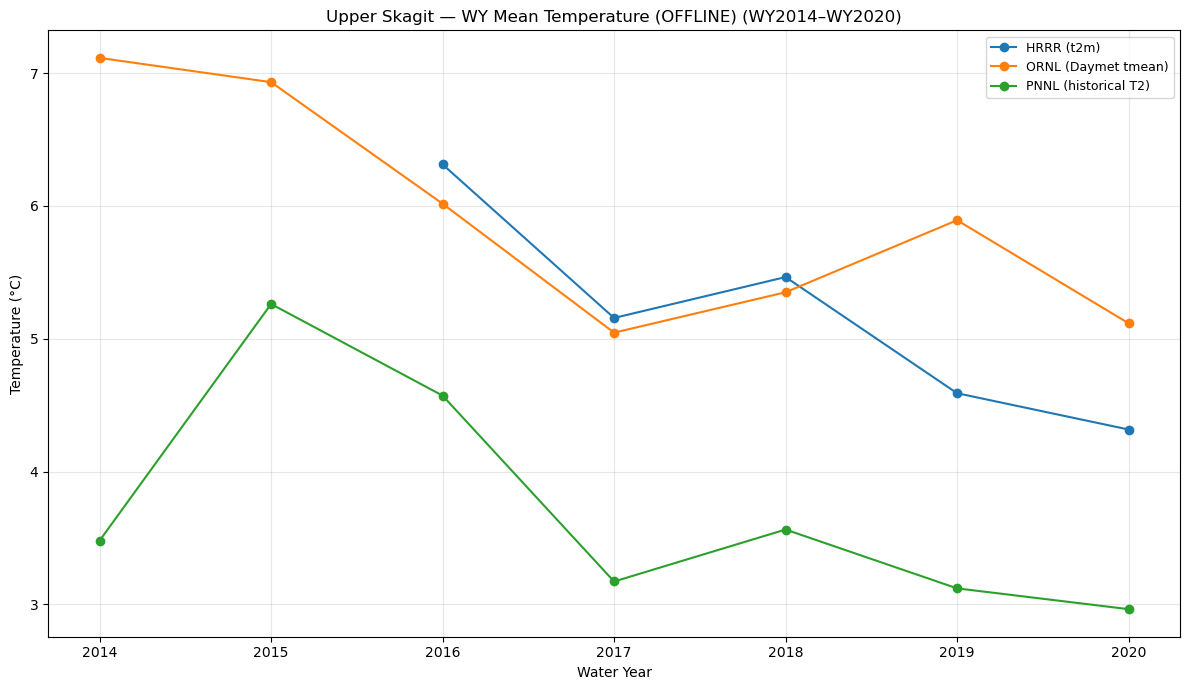

Saved plot → /data0/balaji24/data/derived/water_year_temp_OFFLINE_Sauk_2014_2020.png


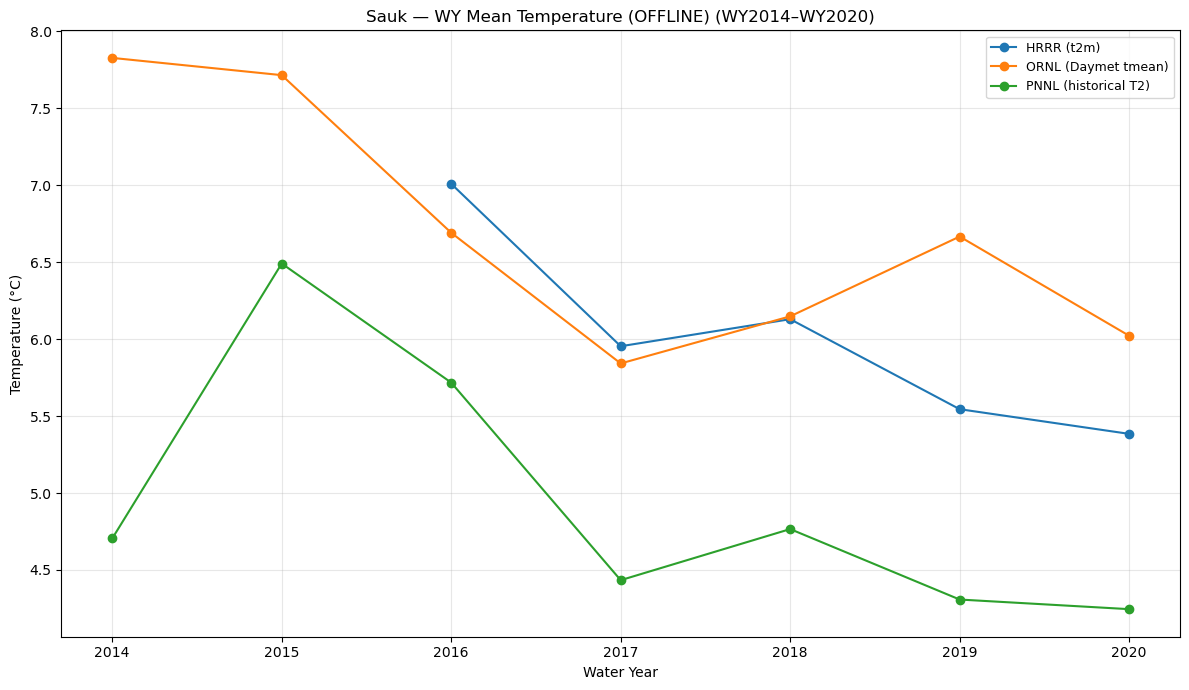

Saved plot → /data0/balaji24/data/derived/water_year_temp_OFFLINE_Lower_Skagit_2014_2020.png


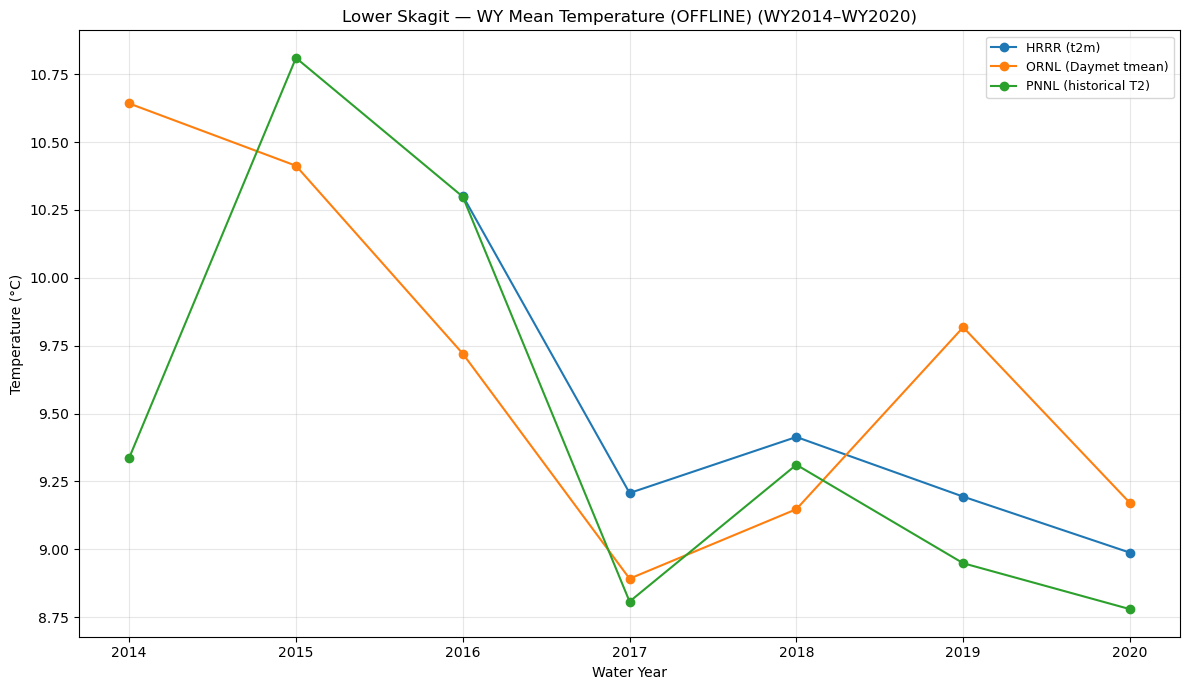

Saved combined plot → /data0/balaji24/data/derived/water_year_temp_OFFLINE_2014_2020.png


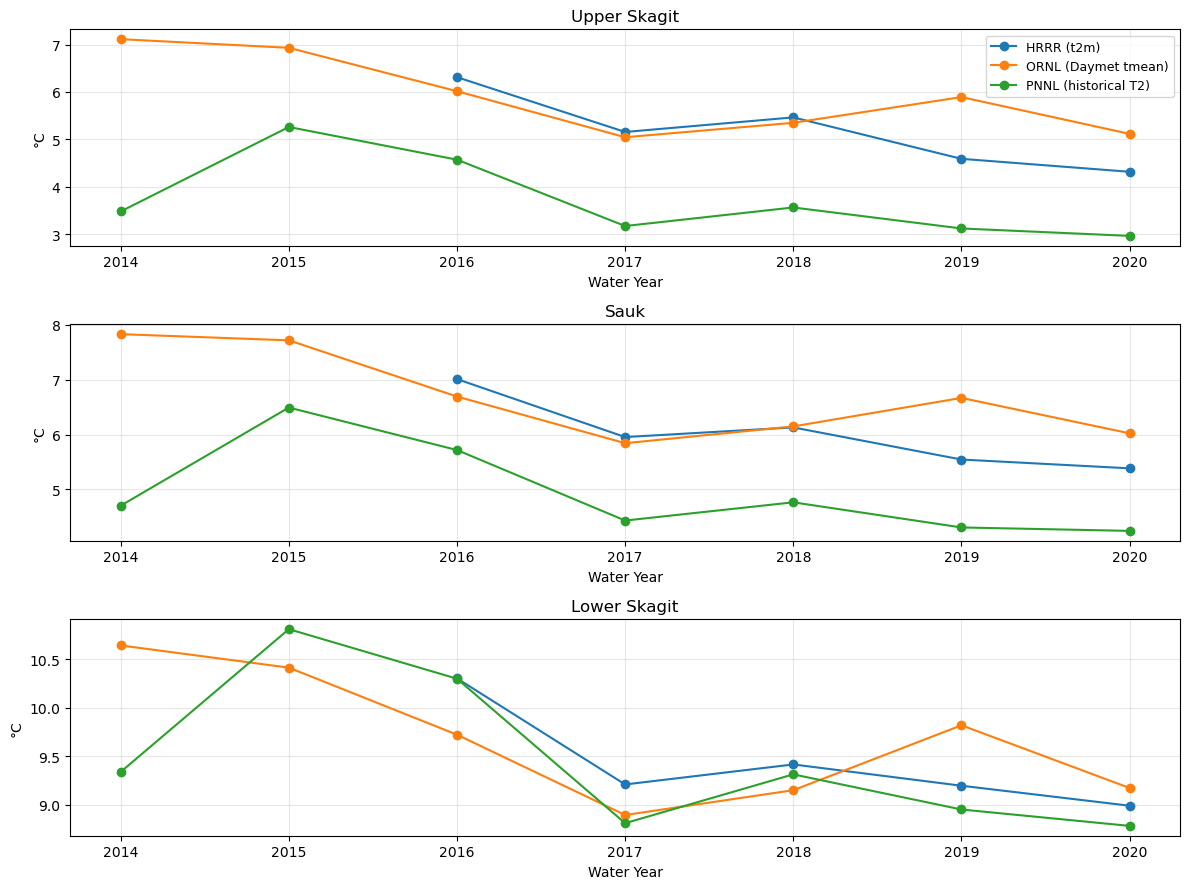

In [ ]:
# ==========================================================
# OFFLINE WY MEAN TEMPERATURE (°C) BY 3 REGIONS (WY2014–WY2020)
# - ORNL Daymet: tmean=(tmin+tmax)/2  (assumed °C; auto-check)
# - HRRR: t2m (K) hourly -> daily mean -> WY mean
# - PNNL: T2 (K) hourly -> daily mean -> WY mean (via region mask)
#
# ALSO PLOTS:
#   1) One figure per region (all offline datasets)
#   2) Combined 3-panel figure
# ==========================================================

import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

P_ORNL_DIR  = BASE / "ornl"
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
PNG_OUT = OUT / f"water_year_temp_OFFLINE_{YEAR_MIN}_{YEAR_MAX}.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    # if values look like Kelvin, convert
    try:
        m = float(da.isel(time=0).mean().compute()) if "time" in da.dims else float(da.mean().compute())
    except Exception:
        m = float(da.isel(time=0).mean()) if "time" in da.dims else float(da.mean())
    return da - 273.15 if m > 150 else da

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_mean(da):
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group": "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

# ---------------- Region mean (same idea as precip code) ----------------
def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds, regions_gdf):
    import regionmask

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

regions_gdf = load_regions_gdf()

rows = []

# ==========================================================
# 1) ORNL Daymet: tmean = (tmin + tmax)/2  -> WY mean
# Robust: skips zarrs missing tmin/tmax (or differently cased)
# ==========================================================
print("[ORNL] Computing WY mean temperature from tmin/tmax...")

ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr")) if P_ORNL_DIR.exists() else []
if not ornl_years:
    print("[ORNL] No ORNL zarrs found -> skipping")
else:
    def _find_var_case_insensitive(ds, target):
        t = target.lower()
        for v in ds.data_vars:
            if v.lower() == t:
                return v
        return None

    tmean_parts = []
    grid_ref_ds = None

    for p in ornl_years:
        ds = safe_open_zarr(p)

        vmin = _find_var_case_insensitive(ds, "tmin")
        vmax = _find_var_case_insensitive(ds, "tmax")

        if (vmin is None) or (vmax is None):
            print(f"[ORNL] skip {p.name}: missing tmin/tmax (vars head={list(ds.data_vars)[:10]})")
            try: ds.close()
            except Exception: pass
            continue

        if grid_ref_ds is None:
            grid_ref_ds = ds

        tmin = ensure_time_sorted_unique(ds[vmin]).sel(time=slice(GLOBAL_START, GLOBAL_END))
        tmax = ensure_time_sorted_unique(ds[vmax]).sel(time=slice(GLOBAL_START, GLOBAL_END))

        if tmin.sizes.get("time", 0) == 0 or tmax.sizes.get("time", 0) == 0:
            print(f"[ORNL] skip {p.name}: no overlap with {GLOBAL_START}..{GLOBAL_END}")
            try: ds.close()
            except Exception: pass
            continue

        tmean = (tmin + tmax) / 2.0
        tmean = to_celsius(tmean)
        tmean.name = "tmean"

        if ds is not grid_ref_ds:
            try: ds.close()
            except Exception: pass

        tmean_parts.append(tmean)

    if tmean_parts:
        tmean_all = xr.concat(tmean_parts, dim="time", join="outer", coords="minimal", compat="override")
        tmean_all = ensure_time_sorted_unique(tmean_all)

        rm = region_mean(tmean_all, grid_ds=grid_ref_ds, regions_gdf=regions_gdf)
        rm = ensure_time_sorted_unique(rm)

        wy = water_year_mean(rm)
        for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
            if wy_i not in wy["year"].values:
                continue
            for r in wy["region"].values:
                val = float(wy.sel(year=wy_i, region=r).values)
                if np.isfinite(val):
                    rows.append({"dataset": "ORNL (Daymet tmean)", "region": str(r), "year": wy_i, "temp_c": val})

    try:
        if grid_ref_ds is not None:
            grid_ref_ds.close()
    except Exception:
        pass

# ==========================================================
# 2) HRRR: t2m (K) hourly -> daily mean -> WY mean
# ==========================================================
print("[HRRR] Computing WY mean temperature from monthly zarrs (t2m)...")

STRICT_HRRR_WY_DAYS = True

monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]

if monthly:
    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    if parts:
        ds0 = safe_open_zarr(parts[0])
        if "t2m" in ds0:
            dsets = [safe_open_zarr(p)[["t2m"]] for p in parts]
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

            da = ensure_time_sorted_unique(ds["t2m"])
            da = to_celsius(da)
            daily = da.resample(time="1D").mean()

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily).sel(time=slice(GLOBAL_START, GLOBAL_END))

            wy_da = water_year_mean(rm_daily)
            yrs_present = sorted({int(y) for y in wy_da["year"].values})
            print(f"[HRRR] WY present in computed series: {yrs_present}")

            def expected_days_in_wy(wy):
                return pd.date_range(wy_start(wy), wy_end(wy), freq="D")

            if STRICT_HRRR_WY_DAYS:
                t_daily = set(pd.to_datetime(rm_daily["time"].values).to_pydatetime())
                good_years = []
                for wy in yrs_present:
                    exp = expected_days_in_wy(wy).to_pydatetime()
                    if all(ts in t_daily for ts in exp):
                        good_years.append(wy)
                    else:
                        print(f"[HRRR] SKIP WY{wy}: incomplete daily coverage")
            else:
                good_years = yrs_present

            for wy_i in good_years:
                for r in wy_da["region"].values:
                    val = float(wy_da.sel(year=wy_i, region=r).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "HRRR (t2m)", "region": str(r), "year": int(wy_i), "temp_c": val})

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds.close()
            except Exception: pass
        else:
            print("[HRRR] 't2m' not found in HRRR zarr")
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No monthly HRRR zarrs found -> skipping")

# ==========================================================
# 3) PNNL historical T2 -> WY mean temp (°C) using REGION MASK
# ==========================================================
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")
print("[PNNL-MASK] Computing WY mean temperature from PNNL T2 using region mask...")

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    mask = mask_ds["mask"]  # (region, y, x)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*T2*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*T2*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files, combine="by_coords", engine="netcdf4", parallel=False,
            preprocess=_preprocess, chunks={"time": 24 * 7}
        )
        if "T2" not in dsp:
            dsp.close()
            continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if t2.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        t2 = to_celsius(t2)
        t2_daily = t2.resample(time="1D").mean()

        spatial_dims = [d for d in t2_daily.dims if d != "time"]
        out_region_daily = []
        for rname in region_labels:
            mr = mask.sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})
            out_region_daily.append(t2_daily.where(mr).mean(dim=spatial_dims, skipna=True))

        region_daily = xr.concat(out_region_daily, dim="region").assign_coords(region=region_labels)
        wy_mean = region_daily.mean("time", skipna=True)

        for rname in region_labels:
            val = float(wy_mean.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "PNNL (historical T2)", "region": str(rname), "year": int(wy), "temp_c": val})

        dsp.close()

    mask_ds.close()
else:
    print("[PNNL-MASK] Missing PNNL_HIST or PNNL_REGION_MASK, skipping.")

print("[PNNL-MASK] Done.")

# ==========================================================
# Result dataframe (offline only)
# ==========================================================
df_off = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

print("\nOFFLINE WY mean temperature (°C):")
print(df_off)

# ==========================================================
# PLOTTING (offline only)
# 1) One figure per region
# 2) Combined 3-panel
# ==========================================================
years = list(range(YEAR_MIN, YEAR_MAX + 1))

# One figure per region
for region in REGION_NAMES:
    sub = df_off[df_off["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    ax.set_title(f"{region} — WY Mean Temperature (OFFLINE) (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    out_png = OUT / f"water_year_temp_OFFLINE_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined 3-panel
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df_off[df_off["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    ax.set_title(region)
    ax.set_xlabel("Water Year")
    ax.set_ylabel("°C")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved combined plot →", PNG_OUT)
plt.show()

[DAYMET-PC] Computing WY mean tmean from Planetary Computer...
[DAYMET-PC] FAILED: TimeoutError()
[UCLA] Computing WY mean t2 from local NetCDFs...
[HRRR] Computing WY mean temp from monthly zarrs (t2m)...


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x716c8d52e050>


[PNNL] Computing WY mean temp from historical T2 using region mask...
[CONUS404-online] Loading via HyTEST intake (best-effort)...
[CONUS404-online] FAILED: RuntimeError("Zstd decompression error: b'Data corruption detected'")
[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...
[SNOTEL-online] Stations inside Skagit polygon: 30
[SNOTEL-online] FAILED: RuntimeError('No TAVG data returned from AWDB API.')

[FINAL] Available datasets: ['HRRR (t2m)', 'PNNL (historical T2)', 'UCLA ERA5 d02 (daily t2)']
      dataset        region  year     temp_c
0  HRRR (t2m)  Lower Skagit  2015  11.587574
1  HRRR (t2m)  Lower Skagit  2016  10.301835
2  HRRR (t2m)  Lower Skagit  2017   9.207541
3  HRRR (t2m)  Lower Skagit  2018   9.413902
4  HRRR (t2m)  Lower Skagit  2019   9.194318

[SNOTEL CHECK] Rows that should drive the dashed line:
Empty DataFrame
Columns: [dataset, region, year, temp_c]
Index: []


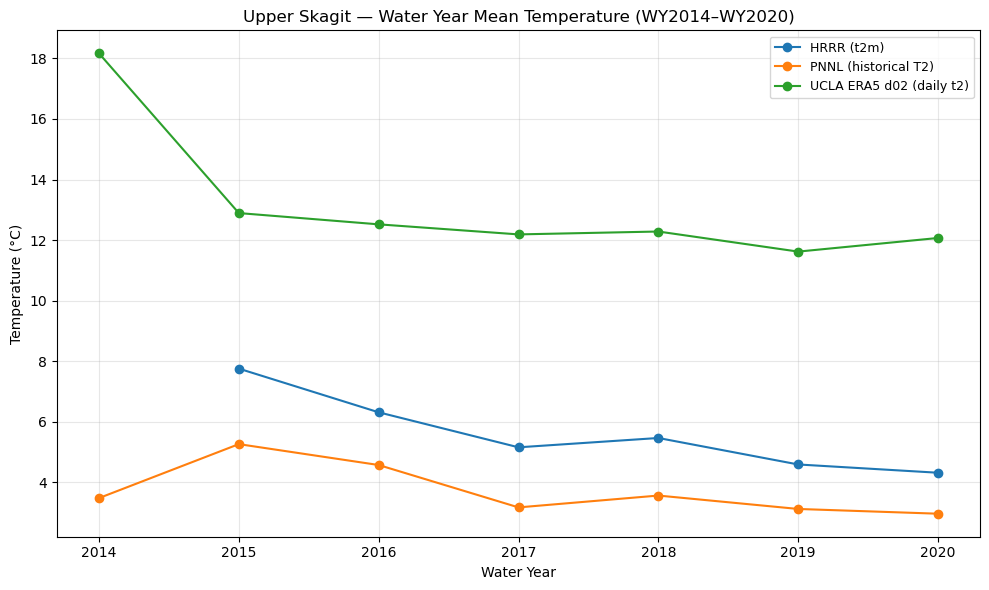

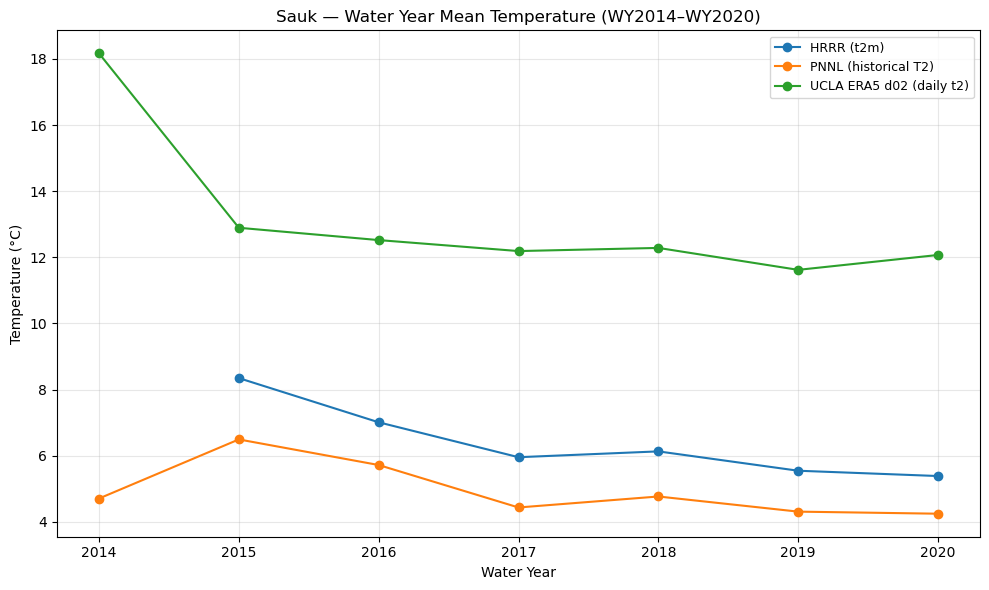

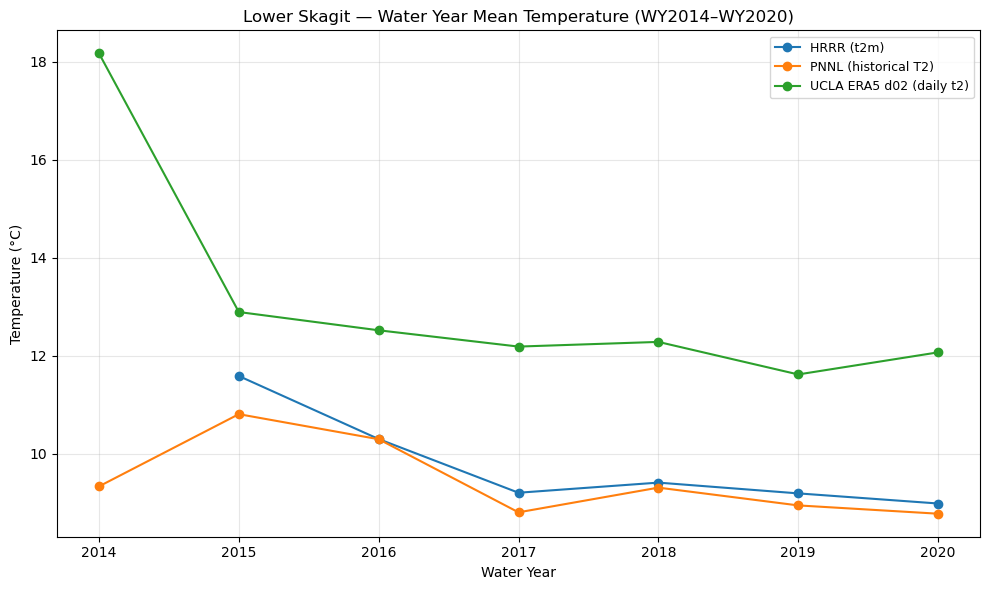

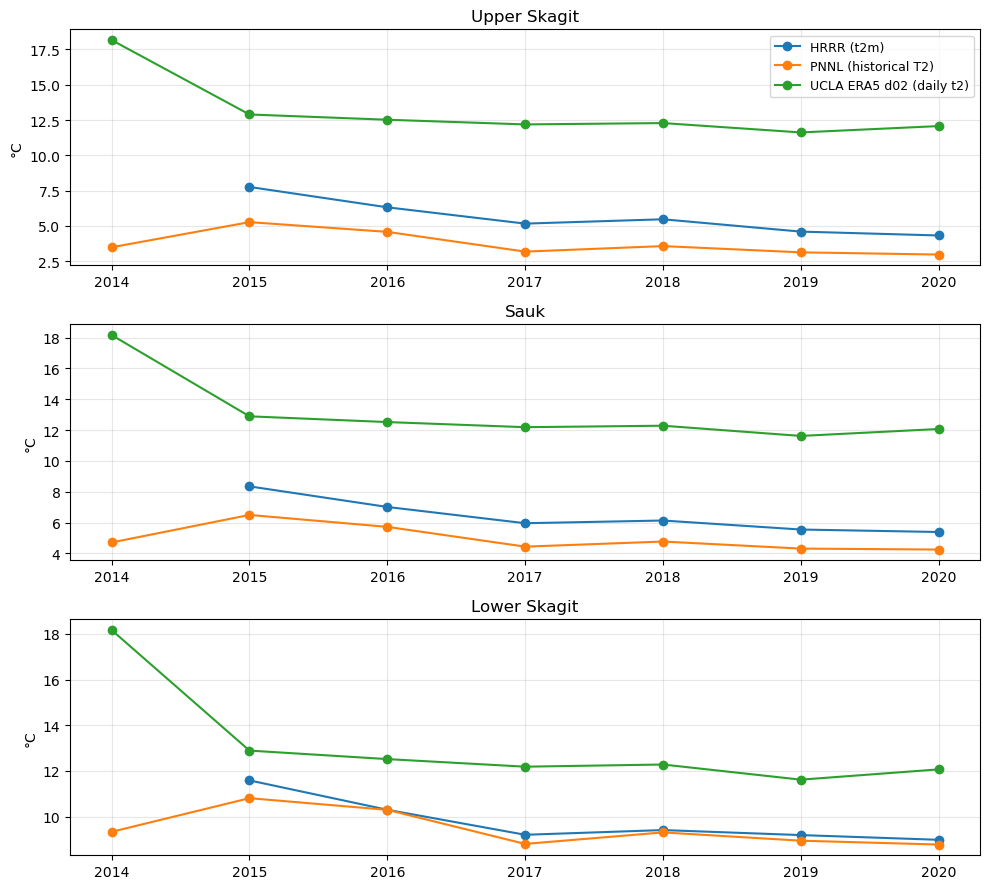

In [ ]:
# ==========================================================
# SINGLE CELL: WY Mean Temperature (°C) by 3 regions (WY2014–WY2020)
# Datasets:
#   - Daymet v4 (Planetary Computer)  [ONLINE]  tmean=(tmin+tmax)/2
#   - UCLA ERA5 d02 daily t2          [LOCAL]   /data0/balaji24/data/ucla_era5_d02_daily/t2/*.nc
#   - HRRR monthly zarrs              [LOCAL]   /data0/balaji24/data/weather_data/YYYY-MM_HRRR_data.zarr
#   - PNNL historical T2              [LOCAL]   /data0/balaji24/data/PNNL/historical + region mask
#   - CONUS404 via HyTEST intake      [ONLINE]  (best-effort; may fail if GitHub blocked)
#   - SNOTEL via AWDB REST API        [ONLINE]  (best-effort; may fail if DNS/internet restricted)
#
# Then: builds df and runs your plotting snippet UNCHANGED.
# ==========================================================

import re, sys, time
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

# UCLA ERA5 d02 daily t2 files (your folder)
UCLA_T2_GLOB = "/data0/balaji24/data/ucla_era5_d02_daily/t2/t2.daily.era5.d02.20*.nc"

# ---------------- Helpers ----------------
def _ensure_time_name(obj):
    """
    Normalize time axis names:
      - rename 'day' -> 'time' (UCLA t2 uses day)
      - rename 'date' -> 'time' (some products)
    Works for both Dataset and DataArray.
    """
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"})
                    break
        return obj
    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"})
                    break
        return obj
    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)
    # heuristic: Kelvin if mean > 150
    try:
        m = float(da.isel(time=0).mean().compute()) if "time" in da.dims else float(da.mean().compute())
    except Exception:
        m = float(da.isel(time=0).mean()) if "time" in da.dims else float(da.mean())
    return da - 273.15 if m > 150 else da

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_mean_over_time(da):
    """WY mean over time dimension (not sum)."""
    da = _ensure_time_name(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group": "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

def find_lat_lon_names(ds):
    # include UCLA lat2d/lon2d
    lat_name = next((n for n in ["lat","latitude","lat2d","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","lon2d","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","lon2d","lat2d")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

def region_mean(da, grid_ds, regions_gdf):
    import regionmask

    da = _ensure_time_name(da)
    grid_ds = _ensure_time_name(grid_ds)

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars:
            return v
    cand_lower = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in cand_lower:
            return v
    return None

regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet v4 (Planetary Computer) — WY mean temp (tmean) by region
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

print("[DAYMET-PC] Computing WY mean tmean from Planetary Computer...")
try:
    ensure_daymet_pkgs()
    from urllib.parse import urlparse, urlunparse
    from pystac_client import Client
    import planetary_computer as pc
    from pyproj import CRS, Transformer
    from fsspec.implementations.http import HTTPFileSystem
    from shapely.ops import transform as shp_transform

    class SASAppendingHTTPFileSystem(HTTPFileSystem):
        def __init__(self, query: str, *args, **kwargs):
            # longer timeout helps with PC slowness
            kwargs.setdefault("timeout", 240)
            super().__init__(*args, **kwargs)
            self._fixed_query = query.lstrip("?")
        def _with_query(self, url: str) -> str:
            u = urlparse(url)
            q = u.query or self._fixed_query
            return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))
        def _open(self, path, mode="rb", block_size=None, **kwargs):
            return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)
        async def _cat_file(self, url, start=None, end=None, **kwargs):
            return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

    def daymet_lcc_crs():
        return CRS.from_proj4(
            "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
            "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
        )

    _DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

    def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
        minx, miny, maxx, maxy = geom_wgs84.bounds
        corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
        xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
        return (float(min(xs) - pad_m), float(max(xs) + pad_m),
                float(min(ys) - pad_m), float(max(ys) + pad_m))

    def _daymet_project_geom_to_xy(geom_ll):
        def _proj(x, y, z=None):
            return _DAYMET_TFM_LL_TO_XY.transform(x, y)
        return shp_transform(_proj, geom_ll)

    _DAYMET_MASK_CACHE = {}

    def get_daymet_mapper():
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
        signed = pc.sign(col.assets[asset_key]).href

        u = urlparse(signed)
        base = f"{u.scheme}://{u.netloc}{u.path}"
        query = u.query
        fs = SASAppendingHTTPFileSystem(query)
        return fs.get_mapper(base)

    def daymet_wy_region_mean_temp(ds_daymet, wy: int, region_name: str, geom_ll):
        t0, t1 = wy_start(wy), wy_end(wy)
        xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

        y0 = float(ds_daymet["y"].values[0])
        y1 = float(ds_daymet["y"].values[-1])
        y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

        tmin = ds_daymet["tmin"].sel(time=slice(t0, t1), x=slice(xmin, xmax), y=y_slice).chunk({"time": 92, "y": 256, "x": 256})
        tmax = ds_daymet["tmax"].sel(time=slice(t0, t1), x=slice(xmin, xmax), y=y_slice).chunk({"time": 92, "y": 256, "x": 256})
        tmean = to_celsius((tmin + tmax) / 2.0)

        key = (float(tmean["x"].values[0]), float(tmean["x"].values[-1]),
               float(tmean["y"].values[0]), float(tmean["y"].values[-1]),
               tmean.sizes["x"], tmean.sizes["y"], region_name)

        mask = _DAYMET_MASK_CACHE.get(key)
        if mask is None:
            xx, yy = xr.broadcast(tmean["x"], tmean["y"])
            geom_xy = _daymet_project_geom_to_xy(geom_ll)
            from shapely import contains_xy
            mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
            mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
            _DAYMET_MASK_CACHE[key] = mask

        bm_daily = tmean.where(mask).mean(dim=("y", "x"), skipna=True)
        return float(bm_daily.mean(dim="time", skipna=True).compute().values)

    regions_ll = regions_gdf.to_crs("EPSG:4326")

    # retry open to reduce TimeoutError pain
    ds_daymet = None
    for attempt in range(1, 4):
        try:
            mapper = get_daymet_mapper()
            ds_daymet = xr.open_zarr(mapper, consolidated=True)
            break
        except Exception as e:
            print(f"[DAYMET-PC] open attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
            ds_daymet = None

    if ds_daymet is None:
        raise TimeoutError("Daymet-PC open failed after retries.")

    if not {"tmin", "tmax"}.issubset(ds_daymet.data_vars):
        raise RuntimeError(f"Daymet missing tmin/tmax. Vars head={list(ds_daymet.data_vars)[:30]}")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        for rname in REGION_NAMES:
            geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
            val = daymet_wy_region_mean_temp(ds_daymet, wy, rname, geom)
            if np.isfinite(val):
                rows.append({"dataset": "Daymet v4 (Planetary Computer)", "region": str(rname), "year": int(wy), "temp_c": float(val)})

    try: ds_daymet.close()
    except Exception: pass

except Exception as e:
    print("[DAYMET-PC] FAILED:", repr(e))

# ==========================================================
# 2) UCLA ERA5 d02 daily t2 — local files  FIXED (day->time + lat2d/lon2d)
# ==========================================================
print("[UCLA] Computing WY mean t2 from local NetCDFs...")
try:
    files = sorted(glob(UCLA_T2_GLOB))
    if not files:
        raise RuntimeError(f"No UCLA files matched: {UCLA_T2_GLOB}")

    ds_u = xr.open_mfdataset(files, combine="by_coords", parallel=False)
    ds_u = _ensure_time_name(ds_u)  # critical

    v = pick_var(ds_u, ["t2", "T2", "t2m", "tas", "temp"])
    if v is None:
        raise RuntimeError(f"Could not find temperature variable in UCLA ds. Vars head={list(ds_u.data_vars)[:30]}")

    da = ensure_time_sorted_unique(ds_u[v]).sel(time=slice(GLOBAL_START, GLOBAL_END))
    da = to_celsius(da)

    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds_u, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "UCLA ERA5 d02 (daily t2)", "region": str(rgn), "year": int(wy_i), "temp_c": val})

    try: ds_u.close()
    except Exception: pass

except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 3) HRRR — local monthly zarrs
# ==========================================================
print("[HRRR] Computing WY mean temp from monthly zarrs (t2m)...")
monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]

if not monthly:
    print("[HRRR] No HRRR monthly zarrs found -> skipping")
else:
    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])
    if not parts:
        print("[HRRR] No overlapping HRRR months -> skipping")
    else:
        ds0 = xr.open_zarr(parts[0], consolidated=False)
        if "t2m" not in ds0:
            print("[HRRR] 't2m' not found -> skipping")
        else:
            dsets = [xr.open_zarr(p, consolidated=False)[["t2m"]] for p in parts]
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

            da = to_celsius(ensure_time_sorted_unique(ds["t2m"]))
            daily = da.resample(time="1D").mean()

            rm_daily = ensure_time_sorted_unique(region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)).sel(
                time=slice(GLOBAL_START, GLOBAL_END)
            )
            wy_da = water_year_mean_over_time(rm_daily)

            for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
                if wy_i not in wy_da["year"].values:
                    continue
                for r in wy_da["region"].values:
                    val = float(wy_da.sel(year=wy_i, region=r).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "HRRR (t2m)", "region": str(r), "year": int(wy_i), "temp_c": val})

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass

# ==========================================================
# 4) PNNL — local historical T2 with region mask
# ==========================================================
print("[PNNL] Computing WY mean temp from historical T2 using region mask...")
if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    mask = mask_ds["mask"]  # (region, y, x)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*T2*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*T2*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files, combine="by_coords", engine="netcdf4", parallel=False,
            preprocess=_preprocess, chunks={"time": 24 * 7}
        )
        dsp = _ensure_time_name(dsp)

        if "T2" not in dsp:
            dsp.close()
            continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if t2.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        t2_daily = to_celsius(t2).resample(time="1D").mean()
        spatial_dims = [d for d in t2_daily.dims if d != "time"]

        out_region_daily = []
        for rname in region_labels:
            mr = mask.sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})
            out_region_daily.append(t2_daily.where(mr).mean(dim=spatial_dims, skipna=True))

        region_daily = xr.concat(out_region_daily, dim="region").assign_coords(region=region_labels)
        wy_mean = region_daily.mean("time", skipna=True)

        for rname in region_labels:
            val = float(wy_mean.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "PNNL (historical T2)", "region": str(rname), "year": int(wy), "temp_c": val})

        dsp.close()

    mask_ds.close()
else:
    print("[PNNL] Missing PNNL_HIST or PNNL_REGION_MASK -> skipping")

# ==========================================================
# 5) CONUS404 online via HyTEST (best-effort)
# ==========================================================
print("[CONUS404-online] Loading via HyTEST intake (best-effort)...")
try:
    import intake
    hytest_url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    hytest_cat = intake.open_catalog(hytest_url)

    conus404_cat_url = hytest_cat["conus404-catalog"].path
    conus404_cat = intake.open_catalog(conus404_cat_url)

    keys = list(conus404_cat)
    osn_keys = [k for k in keys if "osn" in k.lower()]
    if not osn_keys:
        raise RuntimeError("No OSN entries found in CONUS404 catalog (or catalog schema changed).")
    used_key = osn_keys[0]
    ds_c = conus404_cat[used_key].to_dask()

    v = pick_var(ds_c, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"Opened {used_key} but no temp var found. Vars head={list(ds_c.data_vars)[:30]}")

    da = ensure_time_sorted_unique(ds_c[v]).sel(time=slice(GLOBAL_START, GLOBAL_END))
    da = to_celsius(da)

    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds_c, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": f"CONUS404 (online:{used_key})", "region": str(rgn), "year": int(wy_i), "temp_c": val})

    print(f"[CONUS404-online] Success: {used_key} var={v}")

except Exception as e:
    print("[CONUS404-online] FAILED:", repr(e))

# ==========================================================
# 6) SNOTEL online via AWDB REST API (best-effort)
# IMPORTANT: We FORCE region="All Stations" so your plotting filter matches.
# ==========================================================
print("[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...")
try:
    import requests
    import geopandas as gpd
    from shapely.geometry import Point

    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    skagit_poly = skagit.geometry.union_all()

    stations_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations"
    r = requests.get(stations_url, params={"networkCds": "SNTL", "stateCds": "WA"}, timeout=120)
    r.raise_for_status()
    st = pd.DataFrame(r.json())

    lat_col = next((c for c in st.columns if c.lower() in ["latitude","lat"]), None)
    lon_col = next((c for c in st.columns if c.lower() in ["longitude","lon","lng"]), None)
    trip_col = next((c for c in st.columns if c.lower() == "stationtriplet"), None)
    if lat_col is None or lon_col is None or trip_col is None:
        raise RuntimeError(f"Unexpected stations schema. Columns: {list(st.columns)}")

    pts = [Point(xy) for xy in zip(st[lon_col].astype(float), st[lat_col].astype(float))]
    inside = [skagit_poly.contains(p) for p in pts]
    st_in = st.loc[inside].copy()
    if st_in.empty:
        raise RuntimeError("No SNOTEL stations found inside Skagit boundary.")

    triplets = st_in[trip_col].astype(str).tolist()
    print(f"[SNOTEL-online] Stations inside Skagit polygon: {len(triplets)}")

    data_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data"
    begin = f"{YEAR_MIN-1}-10-01 00:00"
    end   = f"{YEAR_MAX}-09-30 00:00"

    def chunks(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i+n]

    all_rows = []
    for ch in chunks(triplets, 75):
        params = {
            "stationTriplets": ",".join(ch),
            "elements": "TAVG",
            "beginDate": begin,
            "endDate": end,
            "duration": "DAILY",
            "centralTendencyType": "NONE",
            "returnFlags": "false",
            "returnOriginalValues": "false",
            "returnSuspectData": "false",
        }
        rr = requests.get(data_url, params=params, timeout=180)
        rr.raise_for_status()
        payload = rr.json()

        for item in payload:
            for d in item.get("data", []):
                dt = pd.to_datetime(d.get("date"), errors="coerce")
                val = pd.to_numeric(d.get("value"), errors="coerce")
                if pd.isna(dt) or pd.isna(val):
                    continue
                all_rows.append((dt, float(val)))

    if not all_rows:
        raise RuntimeError("No TAVG data returned from AWDB API.")

    daily = pd.DataFrame(all_rows, columns=["time", "temp"])
    if daily["temp"].mean() > 45:
        daily["temp"] = (daily["temp"] - 32) * (5/9)

    basin_daily = daily.groupby("time", as_index=False)["temp"].mean()
    basin_daily = basin_daily[(basin_daily["time"] >= GLOBAL_START) & (basin_daily["time"] <= GLOBAL_END)]

    wy = basin_daily["time"].dt.year.where(basin_daily["time"].dt.month < 10, basin_daily["time"].dt.year + 1)
    basin_daily["year"] = wy.astype(int)

    basin_wy = basin_daily.groupby("year", as_index=False)["temp"].mean()
    basin_wy = basin_wy[(basin_wy["year"] >= YEAR_MIN) & (basin_wy["year"] <= YEAR_MAX)].sort_values("year")

    for _, r in basin_wy.iterrows():
        rows.append({"dataset": "SNOTEL (mean stations)", "region": "All Stations", "year": int(r["year"]), "temp_c": float(r["temp"])})

    print("[SNOTEL-online] Added basin WY series as region='All Stations'.")

except Exception as e:
    print("[SNOTEL-online] FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head())

print("\n[SNOTEL CHECK] Rows that should drive the dashed line:")
print(df[(df["dataset"]=="SNOTEL (mean stations)")].sort_values(["region","year"]).head(50))

# ==========================================================
# PLOTTING 
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Pull SNOTEL series once
snotel = df[(df["dataset"] == "SNOTEL (mean stations)") & (df["region"] == "All Stations")].copy()
snotel = snotel.sort_values("year")

# ---------------- One figure per region ----------------
for region in REGION_NAMES:
    fig = plt.figure(figsize=(10, 6))
    ax = plt.gca()

    sub = df[df["region"] == region].copy()

    # Plot region datasets
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    # Plot SNOTEL reference (same line on all regions)
    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(f"{region} — Water Year Mean Temperature (WY2014–WY2020)")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# ---------------- Combined 3-panel ----------------
fig = plt.figure(figsize=(10, 9))

for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)

    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(region)
    ax.set_ylabel("°C")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

[SNOTEL] Stations inside polygon total=30, SNTL-only=9
[SNOTEL] extracted (date,value) pairs: 19972
     wy    temp_c
0  2014  4.847133
1  2015  6.139593
2  2016  5.290257
3  2017  4.379148
4  2018  4.640794
5  2019  4.530879
6  2020  3.743123


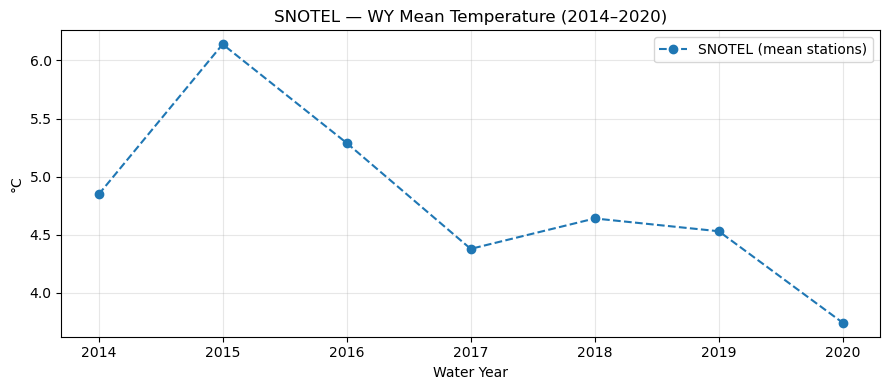

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import requests

BOUNDARY_GEO = "../data/GIS/SkagitBoundary.json"
YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------------- stations in polygon ----------------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
skagit_poly = skagit.geometry.union_all()

stations_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations"
r = requests.get(stations_url, params={"networkCds": "SNTL", "stateCds": "WA"}, timeout=60)
r.raise_for_status()
st = pd.DataFrame(r.json())

lat_col = next((c for c in st.columns if c.lower() in ["latitude","lat"]), None)
lon_col = next((c for c in st.columns if c.lower() in ["longitude","lon","lng"]), None)
trip_col = next((c for c in st.columns if c.lower() == "stationtriplet"), None)
assert lat_col and lon_col and trip_col, f"Unexpected schema: {list(st.columns)}"

pts = [Point(xy) for xy in zip(st[lon_col].astype(float), st[lat_col].astype(float))]
inside = [skagit_poly.contains(p) for p in pts]
triplets_all = st.loc[inside, trip_col].astype(str).tolist()

# Keep only true SNOTEL triplets (WA:SNTL)
triplets = [t for t in triplets_all if t.endswith(":WA:SNTL")]
print(f"[SNOTEL] Stations inside polygon total={len(triplets_all)}, SNTL-only={len(triplets)}")

if not triplets:
    raise RuntimeError("No SNTL stations found in polygon after filtering.")

# ---------------- fetch data ----------------
data_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data"
begin = f"{YEAR_MIN-1}-10-01 00:00"
end   = f"{YEAR_MAX}-09-30 23:59"

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_pairs_awdb(payload):
    """
    Payload shape observed:
      list of {"stationTriplet": "...", "data": [
          {"stationElement": {...}, "values": [{"date":"YYYY-MM-DD","value":...}, ...]},
          ...
      ]}
    We extract all (date,value) from all stationElements.
    """
    out = []
    if not isinstance(payload, list):
        return out

    for item in payload:
        if not isinstance(item, dict):
            continue
        data_list = item.get("data", [])
        if not isinstance(data_list, list):
            continue
        for block in data_list:
            if not isinstance(block, dict):
                continue
            vals = block.get("values", [])
            if not isinstance(vals, list):
                continue
            for v in vals:
                dt = pd.to_datetime(v.get("date"), errors="coerce")
                val = pd.to_numeric(v.get("value"), errors="coerce")
                if pd.isna(dt) or pd.isna(val):
                    continue
                out.append((dt, float(val)))
    return out

all_pairs = []
for ch in chunks(triplets, 25):  # smaller chunk size = safer
    params = {
        "stationTriplets": ",".join(ch),
        "elements": "TAVG",
        "beginDate": begin,
        "endDate": end,
        "duration": "DAILY",
        "centralTendencyType": "NONE",
        "returnFlags": "false",
        "returnOriginalValues": "false",
        "returnSuspectData": "false",
    }
    rr = requests.get(data_url, params=params, timeout=120)
    rr.raise_for_status()
    all_pairs.extend(extract_pairs_awdb(rr.json()))

print("[SNOTEL] extracted (date,value) pairs:", len(all_pairs))
if not all_pairs:
    raise RuntimeError("No TAVG values extracted. (Try TMAX/TMIN/TOBS next.)")

df_daily = pd.DataFrame(all_pairs, columns=["time", "temp_f"]).dropna()
df_daily["time"] = pd.to_datetime(df_daily["time"])
df_daily = df_daily[(df_daily["time"] >= GLOBAL_START) & (df_daily["time"] <= GLOBAL_END)]

# Convert F -> C (AWDB says storedUnitCode degF in your response)
df_daily["temp_c"] = (df_daily["temp_f"] - 32) * (5/9)

# Basin daily mean across stations (we don't have station IDs in extracted pairs; it's already pooled)
# But since we pooled all stations together, this is equivalent to averaging across station-days.
basin_daily = df_daily.groupby("time", as_index=False)["temp_c"].mean()

basin_daily["wy"] = np.where(
    basin_daily["time"].dt.month >= 10,
    basin_daily["time"].dt.year + 1,
    basin_daily["time"].dt.year,
)

df_wy = basin_daily.groupby("wy", as_index=False)["temp_c"].mean()
df_wy = df_wy[(df_wy["wy"] >= YEAR_MIN) & (df_wy["wy"] <= YEAR_MAX)].sort_values("wy")

print(df_wy)

plt.figure(figsize=(9,4))
plt.plot(df_wy["wy"], df_wy["temp_c"], marker="o", linestyle="--", label="SNOTEL (mean stations)")
plt.title(f"SNOTEL — WY Mean Temperature ({YEAR_MIN}–{YEAR_MAX})")
plt.xlabel("Water Year"); plt.ylabel("°C")
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

#  Daymet ORNL Temperature

tmin files: 11 good: 7
tmax files: 11 good: 7
years with BOTH tmin+tmax: [2014, 2015, 2016, 2017, 2018, 2019, 2020]
Bad/empty tmin years: [2021, 2022, 2023, 2024]
Bad/empty tmax years: [2021, 2022, 2023, 2024]


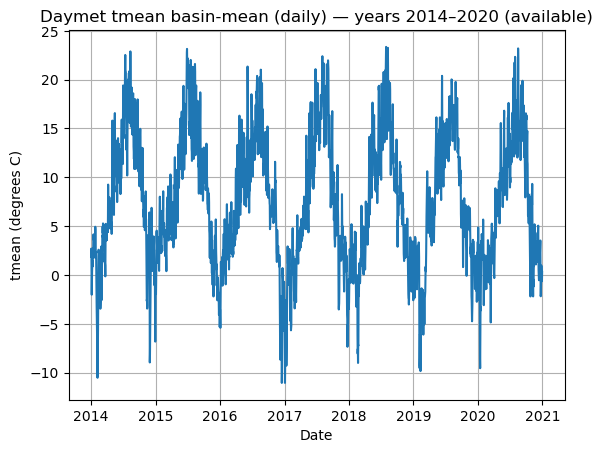

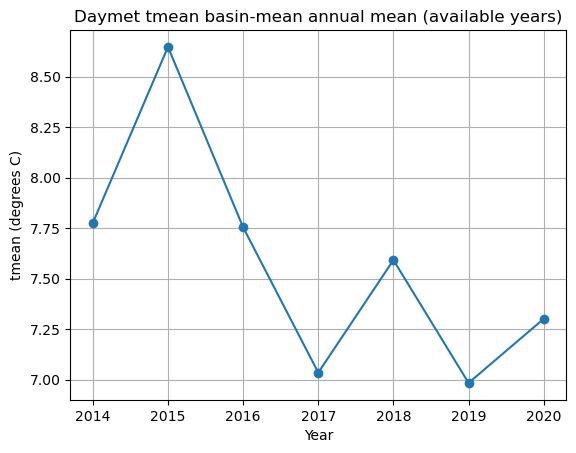

In [4]:
import glob, re
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DIR = "/data0/balaji24/data/daymet_nc_2014_2024"

def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", p)
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0) and (ds.sizes.get("y", 0) > 0) and (ds.sizes.get("x", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

tmin_files = sorted(glob.glob(f"{DIR}/daymet_tmin_*.nc"))
tmax_files = sorted(glob.glob(f"{DIR}/daymet_tmax_*.nc"))

tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}

years = sorted(set(tmin_good.keys()) & set(tmax_good.keys()))
print("tmin files:", len(tmin_files), "good:", len(tmin_good))
print("tmax files:", len(tmax_files), "good:", len(tmax_good))
print("years with BOTH tmin+tmax:", years)

bad_tmin = sorted(set(year_from_path(f) for f in tmin_files if year_from_path(f) is not None) - set(tmin_good.keys()))
bad_tmax = sorted(set(year_from_path(f) for f in tmax_files if year_from_path(f) is not None) - set(tmax_good.keys()))
if bad_tmin:
    print("Bad/empty tmin years:", bad_tmin)
if bad_tmax:
    print("Bad/empty tmax years:", bad_tmax)

if not years:
    raise RuntimeError("No overlapping good years yet. Re-download the missing/empty years.")

# open only matched good files
min_list = [tmin_good[y] for y in years]
max_list = [tmax_good[y] for y in years]

ds_min = xr.open_mfdataset(min_list, combine="by_coords", parallel=False)
ds_max = xr.open_mfdataset(max_list, combine="by_coords", parallel=False)

# align on common time/y/x (just in case)
tmin = ds_min["tmin"]
tmax = ds_max["tmax"]
tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

tmean = (tmin2 + tmax2) / 2.0
tmean.name = "tmean"
tmean.attrs["units"] = tmin.attrs.get("units", "degrees C")

bm = tmean.mean(dim=("y","x"), skipna=True).sortby("time")

plt.figure()
plt.plot(pd.to_datetime(bm["time"].values), bm.values)
plt.title(f"Daymet tmean basin-mean (daily) — years {years[0]}–{years[-1]} (available)")
plt.xlabel("Date")
plt.ylabel(f"tmean ({tmean.attrs.get('units','')})")
plt.grid(True)
plt.show()

annual = bm.groupby("time.year").mean("time")
plt.figure()
plt.plot(annual["year"].values, annual.values, marker="o")
plt.title("Daymet tmean basin-mean annual mean (available years)")
plt.xlabel("Year")
plt.ylabel(f"tmean ({tmean.attrs.get('units','')})")
plt.grid(True)
plt.show()

ds_min.close()
ds_max.close()

[CONUS404] Opening HyTEST catalog...
[CONUS404] Using entry: conus404-daily-osn
                       dataset        region  year    temp_c
0  CONUS404:conus404-daily-osn  Skagit Basin  2014  4.992085
1  CONUS404:conus404-daily-osn  Skagit Basin  2015  6.577100
2  CONUS404:conus404-daily-osn  Skagit Basin  2016  5.685421
3  CONUS404:conus404-daily-osn  Skagit Basin  2017  4.690133
4  CONUS404:conus404-daily-osn  Skagit Basin  2018  5.061233
5  CONUS404:conus404-daily-osn  Skagit Basin  2019  4.960455
6  CONUS404:conus404-daily-osn  Skagit Basin  2020  4.674294


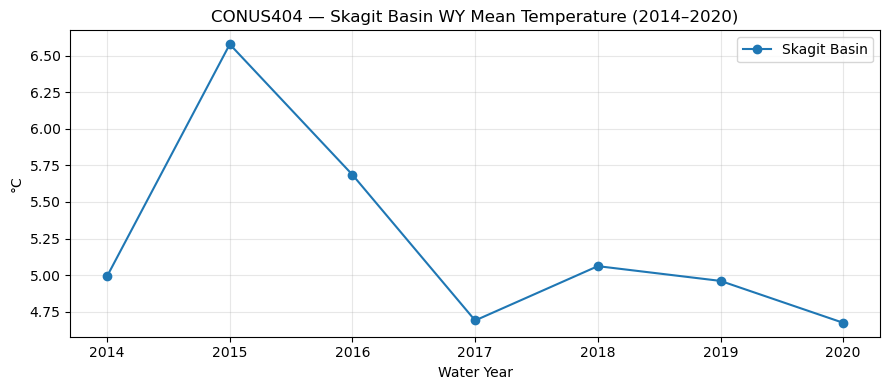

In [6]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import intake
import geopandas as gpd
import regionmask

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"
BOUNDARY_GEO = "../data/GIS/SkagitBoundary.json"

def to_celsius(da):
    # Kelvin->C heuristic
    m = float(da.isel(time=0).mean().compute())
    return da - 273.15 if m > 150 else da

def water_year_mean(da):
    wy = xr.where(da["time"].dt.month >= 10, da["time"].dt.year + 1, da["time"].dt.year)
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group": "year"})
    return out

# ------------------------------------------------------------
# Skagit basin geometry (single polygon)
# ------------------------------------------------------------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
try:
    skagit_geom = skagit.geometry.union_all()
except Exception:
    skagit_geom = skagit.geometry.unary_union

# ------------------------------------------------------------
# Open CONUS404 (HyTEST)
# ------------------------------------------------------------
print("[CONUS404] Opening HyTEST catalog...")
hytest = intake.open_catalog(
    "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
)
conus_cat = intake.open_catalog(hytest["conus404-catalog"].path)

preferred = ["conus404-biasadjusted-daily-osn", "conus404-daily-osn", "conus404-hourly-osn"]
key = next((k for k in preferred if k in conus_cat), None)
if key is None:
    osn = [k for k in list(conus_cat) if "osn" in k.lower()]
    if not osn:
        raise RuntimeError("No OSN entries found in conus404 catalog.")
    key = osn[0]

print("[CONUS404] Using entry:", key)
ds = conus_cat[key].to_dask()

# pick temp var
v = None
for cand in ["t2m", "tas", "T2", "temp", "temperature"]:
    if cand in ds.data_vars:
        v = cand
        break
if v is None:
    raise RuntimeError("No temperature variable found. Vars head: " + str(list(ds.data_vars)[:30]))

# ------------------------------------------------------------
# Slice time + convert to Celsius
# ------------------------------------------------------------
da = ds[v].sel(time=slice(GLOBAL_START, GLOBAL_END))
da = to_celsius(da)

# ------------------------------------------------------------
# Basin mask (single region: Skagit)
# ------------------------------------------------------------
lon = ds["lon"]
lat = ds["lat"]

reg = regionmask.Regions(outlines=[skagit_geom], names=["Skagit Basin"], numbers=[0], name="Skagit")
rid = reg.mask(lon, lat)

# weight mask: 1 inside, NaN outside
w = xr.where(rid == 0, 1.0, np.nan)

# basin mean over spatial dims
spatial_dims = [d for d in da.dims if d != "time"]
bm = (da * w).mean(dim=spatial_dims, skipna=True)

# WY mean
wy = water_year_mean(bm)

# ------------------------------------------------------------
# Build df + plot
# ------------------------------------------------------------
rows = []
for yr in range(YEAR_MIN, YEAR_MAX + 1):
    if yr in wy["year"].values:
        rows.append({
            "dataset": f"CONUS404:{key}",
            "region": "Skagit Basin",
            "year": int(yr),
            "temp_c": float(wy.sel(year=yr).values),
        })

df_conus = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
print(df_conus)

plt.figure(figsize=(9, 4))
plt.plot(df_conus["year"], df_conus["temp_c"], marker="o", label="Skagit Basin")
plt.title(f"CONUS404 — Skagit Basin WY Mean Temperature ({YEAR_MIN}–{YEAR_MAX})")
plt.xlabel("Water Year")
plt.ylabel("°C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...
[UCLA] Computing WY mean t2 from local NetCDFs (coord-mask, per region)...
[HRRR] Computing WY mean temp from monthly zarrs (t2m)...
[PNNL] Computing WY mean temp from historical T2 using geo_em lat/lon masks...
[CONUS404-online] Loading via HyTEST intake (best-effort)...
[CONUS404-online] Success: conus404-hourly-osn var=T2
[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...
[SNOTEL-online] Added basin WY series as region='All Stations'.

[FINAL] Available datasets: ['CONUS404 (online:conus404-hourly-osn)', 'Daymet v4 (local tmean)', 'HRRR (t2m)', 'PNNL (historical T2)', 'SNOTEL (mean stations)', 'UCLA ERA5 d02 (daily t2)']
                                 dataset        region  year     temp_c
0                 SNOTEL (mean stations)  All Stations  2014   4.847133
1                 SNOTEL (mean stations)  All Stations  2015   6.139593
2                 SNOTEL (mean stations)  All Stations  2016   5.290257

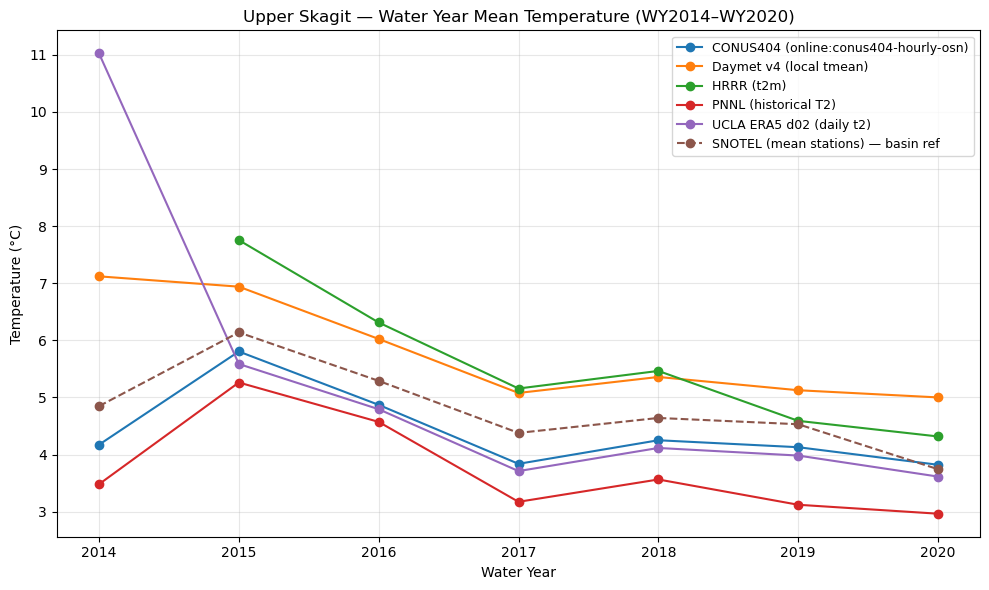

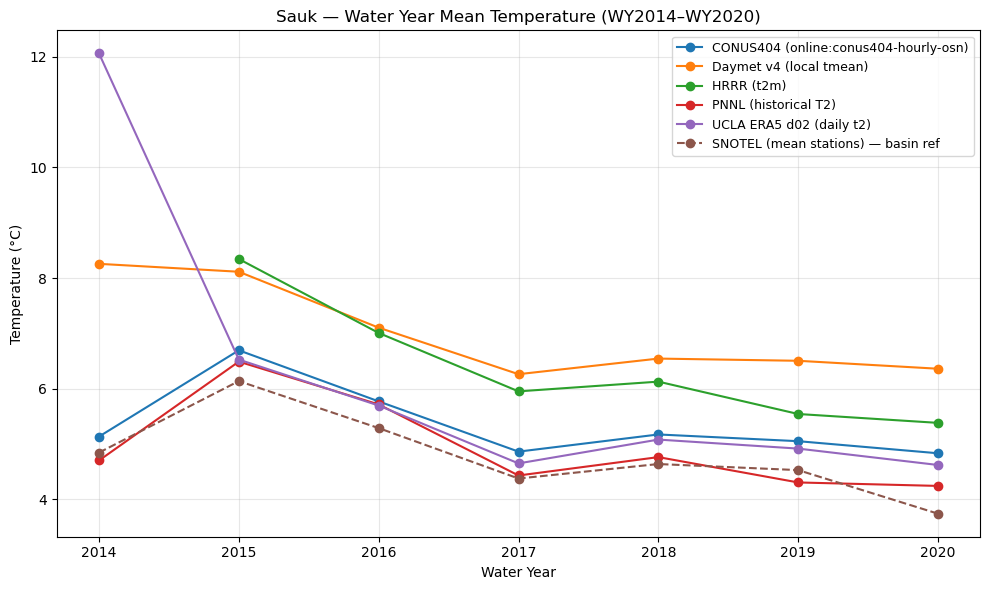

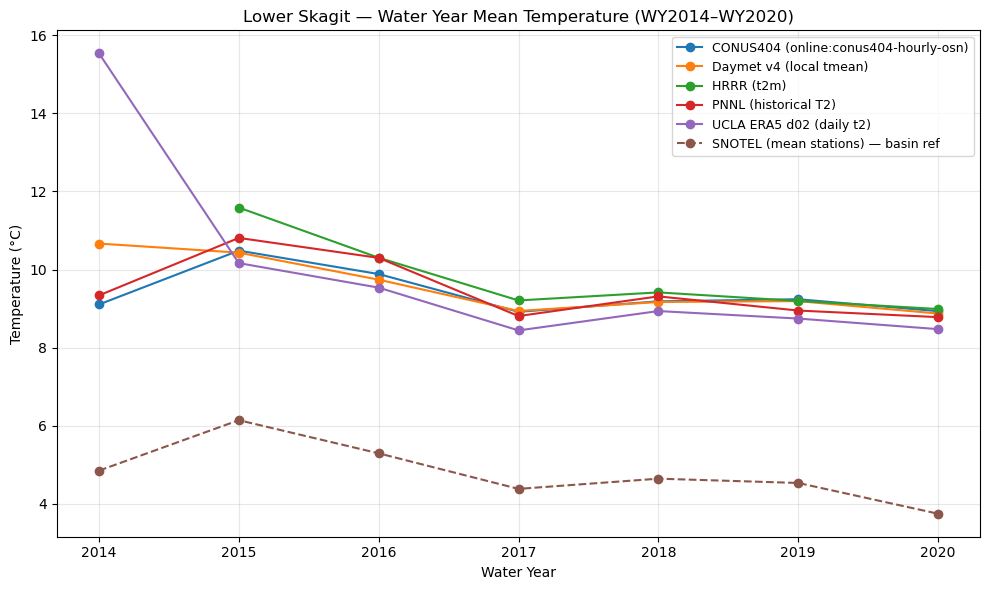

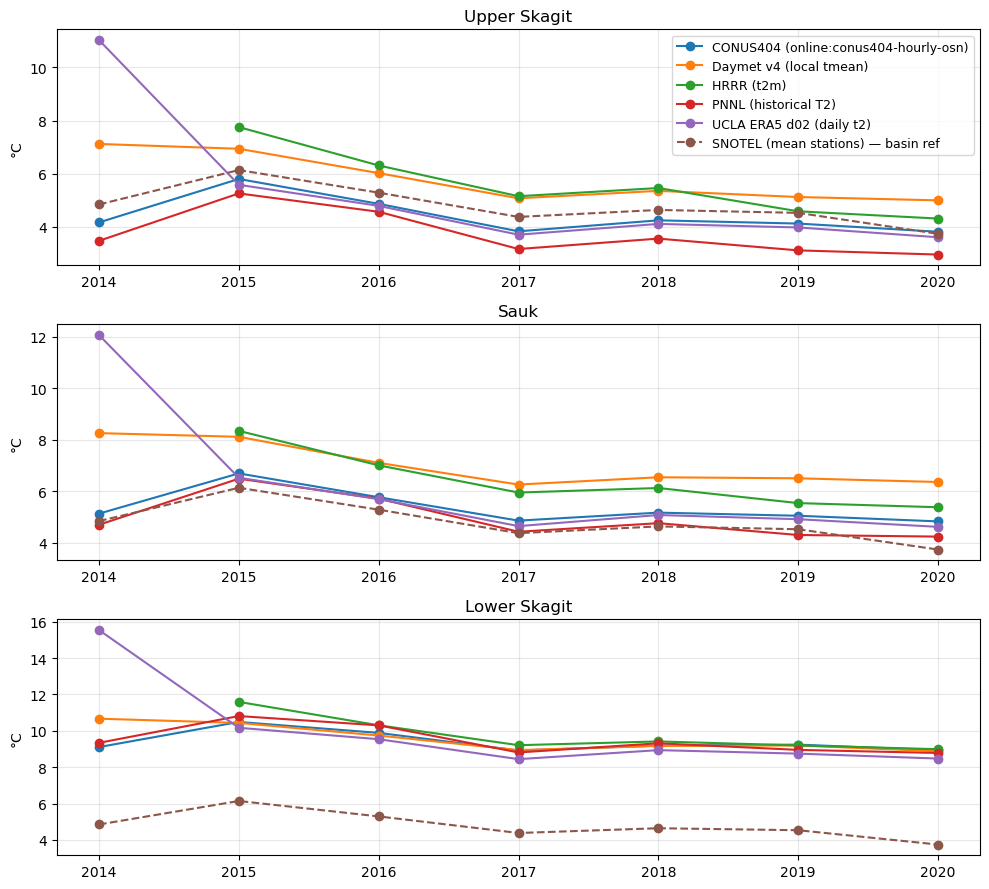

In [ ]:
# ==========================================================
# SINGLE CELL: WY Mean Temperature (°C) by 3 regions (WY2014–WY2020)
#
# Datasets (best-effort; skip if missing):
#   - Daymet (LOCAL yearly NetCDFs): tmean=(tmin+tmax)/2
#   - UCLA ERA5 d02 daily t2 (LOCAL): per-region masks via coord file + contains_xy fallback
#   - HRRR monthly zarrs (LOCAL): t2m
#   - PNNL historical T2 (LOCAL): FIXED: build region masks from PNNL geo_em lat/lon, apply to T2 grid
#   - CONUS404 (ONLINE HyTEST): best-effort (may warn on duplicate dims; we patch common cases)
#   - SNOTEL (ONLINE AWDB): basin ref only (region="All Stations")
#
# Output:
#   - df = [dataset, region, year, temp_c] then your plotting code.
# ==========================================================

import re, glob, time
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# Local datasets
P_HRRR_DIR  = BASE / "weather_data"
PNNL_HIST   = BASE / "PNNL" / "historical"
PNNL_GEO    = PNNL_HIST / "SERDP6km.geo_em.d01.nc"

# UCLA ERA5 d02 daily t2 files
UCLA_T2_GLOB     = "/data0/balaji24/data/ucla_era5_d02_daily/t2/t2.daily.era5.d02.20*.nc"
UCLA_COORD_FILE  = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# Daymet local yearly NetCDFs (downloaded)
DAYMET_DIR = "/data0/balaji24/data/daymet_nc_2014_2024"
DAYMET_TMIN_GLOB = f"{DAYMET_DIR}/daymet_tmin_*.nc"
DAYMET_TMAX_GLOB = f"{DAYMET_DIR}/daymet_tmax_*.nc"

# ---------------- Helpers ----------------
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"}); break
        return obj
    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        return obj
    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)
    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean().compute()) if hasattr(probe.data, "compute") else float(probe.mean())
    except Exception:
        m = 0.0
    return da - 273.15 if m > 150 else da

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_mean_over_time(da):
    da = _ensure_time_name(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).mean("time", skipna=True)
    if "group" in out.dims:
        out = out.rename({"group": "year"})
    return out

def wy_start(wy): return f"{wy-1}-10-01"
def wy_end(wy):   return f"{wy}-09-30"

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars: return v
    cl = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in cl: return v
    return None

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","lat2d","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","lon2d","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","lon2d","lat2d","south_north","west_east")]
        if not extra: break
        arr = arr.isel({extra[0]: 0})
    return arr

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

def region_mean(da, grid_ds, regions_gdf):
    import regionmask
    da = _ensure_time_name(da)
    grid_ds = _ensure_time_name(grid_ds)

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

def year_from_path(p):
    m = re.search(r"_(\d{4})\.nc$", p)
    return int(m.group(1)) if m else None

def good_file(p, var):
    try:
        ds = xr.open_dataset(p)
        ok = (var in ds.data_vars) and (ds.sizes.get("time", 0) > 0) and (ds.sizes.get("y", 0) > 0) and (ds.sizes.get("x", 0) > 0)
        ds.close()
        return ok
    except Exception:
        return False

# robust contains_xy across shapely versions
def contains_xy_mask(geom, xs, ys):
    # Shapely 2.x
    try:
        import shapely
        cx = getattr(shapely, "contains_xy", None)
        if callable(cx):
            return np.asarray(cx(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    # Shapely <2
    try:
        from shapely.vectorized import contains as vcontains
        return np.asarray(vcontains(geom, xs, ys), dtype=bool)
    except Exception:
        pass
    # fallback slow
    import shapely as _sh
    from shapely.prepared import prep
    pg = prep(geom)
    return np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(xs, ys)], dtype=bool)

def fix_duplicate_dims_da(da: xr.DataArray) -> xr.DataArray:
    dims = list(da.dims)
    if len(dims) == len(set(dims)):
        return da
    if da.ndim == 2 and dims == ["y", "y"]:
        da.dims = ("y", "x"); return da
    if da.ndim == 2 and dims == ["x", "x"]:
        da.dims = ("y", "x"); return da
    seen, new_dims = {}, []
    for d in dims:
        seen[d] = seen.get(d, 0) + 1
        new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
    da.dims = tuple(new_dims)
    return da

def fix_duplicate_dims(ds: xr.Dataset) -> xr.Dataset:
    for name, var in ds.variables.items():
        dims = list(getattr(var, "dims", ()))
        if len(dims) == len(set(dims)):
            continue
        if getattr(var, "ndim", 0) == 2 and dims == ["y", "y"]:
            ds[name].dims = ("y", "x"); continue
        if getattr(var, "ndim", 0) == 2 and dims == ["x", "x"]:
            ds[name].dims = ("y", "x"); continue
        seen, new_dims = {}, []
        for d in dims:
            seen[d] = seen.get(d, 0) + 1
            new_dims.append(d if seen[d] == 1 else f"{d}{seen[d]-1}")
        ds[name].dims = tuple(new_dims)
    return ds

# FIXED: one-to-one mapping so (450,450) never collapses into (450,)
def align_mask_to_da(mask_da: xr.DataArray, da: xr.DataArray) -> xr.DataArray:
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Expected 2 spatial dims, got {spatial}")

    mask_da = mask_da.squeeze(drop=True)
    mask_da = fix_duplicate_dims_da(mask_da)
    if mask_da.ndim != 2:
        raise RuntimeError(f"Mask must be 2D; got dims={mask_da.dims}, shape={mask_da.shape}")

    mdims = list(mask_da.dims)

    # 1) exact-name mapping first
    rename_map = {}
    used_sd = set()
    for md in mdims:
        if md in spatial:
            rename_map[md] = md
            used_sd.add(md)

    # 2) remaining mapping by size WITHOUT reusing a target dim
    remaining_md = [md for md in mdims if md not in rename_map]
    remaining_sd = [sd for sd in spatial if sd not in used_sd]

    for md in remaining_md:
        matched = None
        for sd in remaining_sd:
            if mask_da.sizes[md] == da.sizes[sd]:
                matched = sd
                break
        if matched is None:
            raise RuntimeError(
                f"Could not map mask dim '{md}' (size={mask_da.sizes[md]}) "
                f"to any of {remaining_sd} with sizes {[da.sizes[s] for s in remaining_sd]}"
            )
        rename_map[md] = matched
        remaining_sd.remove(matched)

    m = mask_da.rename(rename_map)

    # transpose to match da dim order
    if set(m.dims) == set(spatial) and list(m.dims) != spatial:
        m = m.transpose(*spatial)

    if (m.sizes.get(spatial[0], -1) != da.sizes[spatial[0]]) or (m.sizes.get(spatial[1], -1) != da.sizes[spatial[1]]):
        raise RuntimeError(
            f"Mask shape {(m.sizes.get(spatial[0]), m.sizes.get(spatial[1]))} "
            f"does not match data grid {(da.sizes[spatial[0]], da.sizes[spatial[1]])}"
        )
    return m


regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# 1) Daymet LOCAL
# ==========================================================
print("[DAYMET-LOCAL] Computing WY mean tmean from local NetCDFs...")
try:
    tmin_files = sorted(glob.glob(DAYMET_TMIN_GLOB))
    tmax_files = sorted(glob.glob(DAYMET_TMAX_GLOB))

    tmin_good = {year_from_path(f): f for f in tmin_files if year_from_path(f) is not None and good_file(f, "tmin")}
    tmax_good = {year_from_path(f): f for f in tmax_files if year_from_path(f) is not None and good_file(f, "tmax")}
    years = sorted([y for y in range(YEAR_MIN-1, YEAR_MAX+1) if (y in tmin_good and y in tmax_good)])
    if not years:
        raise RuntimeError("No overlapping good tmin/tmax years found. (Need tmax years downloaded too.)")

    ds_min = xr.open_mfdataset([tmin_good[y] for y in years], combine="by_coords", parallel=False)
    ds_max = xr.open_mfdataset([tmax_good[y] for y in years], combine="by_coords", parallel=False)

    tmin = ensure_time_sorted_unique(ds_min["tmin"])
    tmax = ensure_time_sorted_unique(ds_max["tmax"])
    tmin2, tmax2 = xr.align(tmin, tmax, join="inner")

    tmean = to_celsius((tmin2 + tmax2) / 2.0).sel(time=slice(GLOBAL_START, GLOBAL_END))
    rm = ensure_time_sorted_unique(region_mean(tmean, grid_ds=ds_min, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": "Daymet v4 (local tmean)", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    ds_min.close(); ds_max.close()
except Exception as e:
    print("[DAYMET-LOCAL] FAILED:", repr(e))

# ==========================================================
# 2) UCLA ERA5 d02
# ==========================================================
print("[UCLA] Computing WY mean t2 from local NetCDFs (coord-mask, per region)...")
try:
    files = sorted(glob.glob(UCLA_T2_GLOB))
    if not files:
        raise RuntimeError(f"No UCLA files matched: {UCLA_T2_GLOB}")
    if not UCLA_COORD_FILE.exists():
        raise RuntimeError(f"Missing UCLA coord file: {UCLA_COORD_FILE}")

    g = xr.open_dataset(UCLA_COORD_FILE, engine="netcdf4")
    lat2d = g["lat2d"].squeeze(drop=True).astype("float64")
    lon2d = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    regions_ll = regions_gdf.to_crs("EPSG:4326")
    lonv = lon2d.values.ravel()
    latv = lat2d.values.ravel()
    ny, nx = lon2d.shape

    ucla_region_masks = {}
    for rname in REGION_NAMES:
        geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
        m_flat = contains_xy_mask(geom, lonv, latv)
        mask2d = m_flat.reshape(ny, nx).astype(bool)
        ucla_region_masks[rname] = xr.DataArray(mask2d, dims=lon2d.dims, coords=lon2d.coords)

    ds_u = xr.open_mfdataset(files, combine="by_coords", parallel=False)
    ds_u = _ensure_time_name(ds_u)

    v = pick_var(ds_u, ["t2", "T2", "t2m", "tas", "temp"])
    if v is None:
        raise RuntimeError(f"Could not find temperature variable in UCLA ds. Vars head={list(ds_u.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_u[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"Unexpected UCLA spatial dims: {spatial}")

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        sub = da.sel(time=slice(wy_start(wy_i), wy_end(wy_i)))
        if sub.sizes.get("time", 0) == 0:
            continue
        for rname in REGION_NAMES:
            m = align_mask_to_da(ucla_region_masks[rname], sub)
            bm_daily = sub.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm_daily.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "UCLA ERA5 d02 (daily t2)", "region": str(rname), "year": int(wy_i), "temp_c": float(wy_mean)})

    ds_u.close()
except Exception as e:
    print("[UCLA] FAILED:", repr(e))

# ==========================================================
# 3) HRRR
# ==========================================================
print("[HRRR] Computing WY mean temp from monthly zarrs (t2m)...")
try:
    monthly = sorted(P_HRRR_DIR.glob("*.zarr")) if P_HRRR_DIR.exists() else []
    monthly = [p for p in monthly if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    if not monthly:
        raise RuntimeError("No HRRR monthly zarrs found")

    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])
    if not parts:
        raise RuntimeError("No overlapping HRRR months for this window")

    ds0 = xr.open_zarr(parts[0], consolidated=False)
    if "t2m" not in ds0:
        raise RuntimeError("HRRR missing 't2m' in monthly zarrs")

    dsets = [xr.open_zarr(p, consolidated=False)[["t2m"]] for p in parts]
    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

    da = to_celsius(ensure_time_sorted_unique(ds["t2m"]))
    daily = da.resample(time="1D").mean()
    rm_daily = ensure_time_sorted_unique(region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)).sel(time=slice(GLOBAL_START, GLOBAL_END))
    wy = water_year_mean_over_time(rm_daily)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for r in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=r).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (t2m)", "region": str(r), "year": int(wy_i), "temp_c": float(val)})

    for d in dsets:
        try: d.close()
        except Exception: pass
    ds.close(); ds0.close()
except Exception as e:
    print("[HRRR] SKIP/FAILED:", repr(e))

# ==========================================================
# 4) PNNL (FIXED: build region masks from geo_em lat/lon)
# ==========================================================
print("[PNNL] Computing WY mean temp from historical T2 using geo_em lat/lon masks...")
try:
    import regionmask

    if not PNNL_HIST.exists():
        raise RuntimeError("Missing PNNL_HIST")
    if not PNNL_GEO.exists():
        raise RuntimeError(f"Missing PNNL geo_em file: {PNNL_GEO}")

    geo = xr.open_dataset(PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat2 = _to_2d(geo[lat_name]).astype("float64")
    lon2 = _to_2d(geo[lon_name]).astype("float64")

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon2, lat2)

    # cache masks as numpy -> then wrap per year to avoid weird coord issues
    pnnl_masks_np = {r: np.asarray((rid == i).data, dtype=bool) for i, r in enumerate(regs.names)}
    rid_dims = rid.dims
    rid_coords = {d: rid[d] for d in rid.dims if d in rid.coords}

    geo.close()

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy-1}" / "*T2*.nc")))
        files += sorted(glob.glob(str(PNNL_HIST / f"{wy}"   / "*T2*.nc")))
        if not files:
            continue

        def _preprocess(ds):
            return ds[["T2"]] if "T2" in ds.data_vars else ds

        dsp = xr.open_mfdataset(
            files, combine="by_coords", engine="netcdf4", parallel=False,
            preprocess=_preprocess, chunks={"time": 24 * 7}
        )
        dsp = _ensure_time_name(dsp)
        dsp = fix_duplicate_dims(dsp)

        if "T2" not in dsp:
            dsp.close(); continue

        t2 = ensure_time_sorted_unique(dsp["T2"]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if t2.sizes.get("time", 0) == 0:
            dsp.close(); continue

        t2_daily = to_celsius(t2).resample(time="1D").mean()
        spatial = [d for d in t2_daily.dims if d != "time"]
        if len(spatial) != 2:
            dsp.close()
            raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

        for rname in REGION_NAMES:
            m_geo = xr.DataArray(pnnl_masks_np[rname], dims=rid_dims, coords=rid_coords)
            m = align_mask_to_da(m_geo, t2_daily)
            bm = t2_daily.where(m).mean(dim=spatial, skipna=True)
            wy_mean = float(bm.mean("time", skipna=True).values)
            if np.isfinite(wy_mean):
                rows.append({"dataset": "PNNL (historical T2)", "region": str(rname), "year": int(wy), "temp_c": float(wy_mean)})

        dsp.close()

except Exception as e:
    print("[PNNL] SKIP/FAILED:", repr(e))

# ==========================================================
# 5) CONUS404 online (best-effort; patch common duplicate dim cases)
# ==========================================================
print("[CONUS404-online] Loading via HyTEST intake (best-effort)...")
try:
    import intake
    ds_cat = intake.open_catalog("https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml")
    conus_url = ds_cat["conus404-catalog"].path
    conus_cat = intake.open_catalog(conus_url)

    osn_keys = [k for k in list(conus_cat) if "osn" in k.lower()]
    if not osn_keys:
        raise RuntimeError("No OSN entries found in CONUS404 catalog")
    used_key = osn_keys[0]

    ds_c = conus_cat[used_key].to_dask()
    ds_c = fix_duplicate_dims(ds_c)
    if "lon" in ds_c: ds_c["lon"] = fix_duplicate_dims_da(ds_c["lon"])
    if "lat" in ds_c: ds_c["lat"] = fix_duplicate_dims_da(ds_c["lat"])

    v = pick_var(ds_c, ["t2m", "tas", "T2", "temp", "temperature"])
    if v is None:
        raise RuntimeError(f"No temp var found. Vars head={list(ds_c.data_vars)[:30]}")

    da = to_celsius(ensure_time_sorted_unique(ds_c[v]).sel(time=slice(GLOBAL_START, GLOBAL_END)))
    rm = ensure_time_sorted_unique(region_mean(da, grid_ds=ds_c, regions_gdf=regions_gdf))
    wy = water_year_mean_over_time(rm)

    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if wy_i not in wy["year"].values:
            continue
        for rgn in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=rgn).values)
            if np.isfinite(val):
                rows.append({"dataset": f"CONUS404 (online:{used_key})", "region": str(rgn), "year": int(wy_i), "temp_c": float(val)})

    print(f"[CONUS404-online] Success: {used_key} var={v}")

except Exception as e:
    print("[CONUS404-online] SKIP/FAILED:", repr(e))

# ==========================================================
# 6) SNOTEL basin ref (All Stations)
# ==========================================================
print("[SNOTEL-online] Fetching daily TAVG via AWDB REST API (best-effort)...")
try:
    import requests
    import geopandas as gpd
    from shapely.geometry import Point

    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        skagit_poly = skagit.geometry.union_all()
    except Exception:
        skagit_poly = skagit.geometry.unary_union

    stations_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations"
    r = requests.get(stations_url, params={"networkCds": "SNTL", "stateCds": "WA"}, timeout=120)
    r.raise_for_status()
    st = pd.DataFrame(r.json())

    lat_col = next((c for c in st.columns if c.lower() in ["latitude","lat"]), None)
    lon_col = next((c for c in st.columns if c.lower() in ["longitude","lon","lng"]), None)
    trip_col = next((c for c in st.columns if c.lower() == "stationtriplet"), None)
    if lat_col is None or lon_col is None or trip_col is None:
        raise RuntimeError(f"Unexpected stations schema. Columns: {list(st.columns)}")

    pts = [Point(xy) for xy in zip(st[lon_col].astype(float), st[lat_col].astype(float))]
    inside = [skagit_poly.contains(p) for p in pts]
    triplets_all = st.loc[inside, trip_col].astype(str).tolist()
    triplets = [t for t in triplets_all if t.endswith(":WA:SNTL")]
    if not triplets:
        raise RuntimeError("No WA:SNTL stations found inside Skagit polygon.")

    data_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data"
    begin = f"{YEAR_MIN-1}-10-01 00:00"
    end   = f"{YEAR_MAX}-09-30 23:59"

    def chunks(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i+n]

    def extract_pairs_awdb(payload):
        out = []
        if not isinstance(payload, list):
            return out
        for item in payload:
            if not isinstance(item, dict):
                continue
            data_list = item.get("data", [])
            if not isinstance(data_list, list):
                continue
            for block in data_list:
                if not isinstance(block, dict):
                    continue
                vals = block.get("values", [])
                if not isinstance(vals, list):
                    continue
                for v in vals:
                    dt = pd.to_datetime(v.get("date"), errors="coerce")
                    val = pd.to_numeric(v.get("value"), errors="coerce")
                    if pd.isna(dt) or pd.isna(val):
                        continue
                    out.append((dt, float(val)))
        return out

    all_pairs = []
    for ch in chunks(triplets, 25):
        params = {
            "stationTriplets": ",".join(ch),
            "elements": "TAVG",
            "beginDate": begin,
            "endDate": end,
            "duration": "DAILY",
            "centralTendencyType": "NONE",
            "returnFlags": "false",
            "returnOriginalValues": "false",
            "returnSuspectData": "false",
        }
        rr = requests.get(data_url, params=params, timeout=180)
        rr.raise_for_status()
        all_pairs.extend(extract_pairs_awdb(rr.json()))

    if not all_pairs:
        raise RuntimeError("No TAVG values extracted from AWDB payload.")

    df_daily = pd.DataFrame(all_pairs, columns=["time", "temp_f"]).dropna()
    df_daily["time"] = pd.to_datetime(df_daily["time"])
    df_daily = df_daily[(df_daily["time"] >= GLOBAL_START) & (df_daily["time"] <= GLOBAL_END)]
    df_daily["temp_c"] = (df_daily["temp_f"] - 32) * (5/9)

    basin_daily = df_daily.groupby("time", as_index=False)["temp_c"].mean()
    basin_daily["wy"] = np.where(basin_daily["time"].dt.month >= 10,
                                 basin_daily["time"].dt.year + 1,
                                 basin_daily["time"].dt.year)
    df_wy = basin_daily.groupby("wy", as_index=False)["temp_c"].mean()
    df_wy = df_wy[(df_wy["wy"] >= YEAR_MIN) & (df_wy["wy"] <= YEAR_MAX)].sort_values("wy")

    for _, r in df_wy.iterrows():
        rows.append({"dataset": "SNOTEL (mean stations)", "region": "All Stations", "year": int(r["wy"]), "temp_c": float(r["temp_c"])})
    print("[SNOTEL-online] Added basin WY series as region='All Stations'.")

except Exception as e:
    print("[SNOTEL-online] SKIP/FAILED:", repr(e))

# ==========================================================
# Build df
# ==========================================================
df = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

print("\n[FINAL] Available datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(10))

# ==========================================================
# PLOTTING 
# ==========================================================
snotel = df[(df["dataset"] == "SNOTEL (mean stations)") & (df["region"] == "All Stations")].copy()
snotel = snotel.sort_values("year")

for region in REGION_NAMES:
    fig = plt.figure(figsize=(10, 6))
    ax = plt.gca()

    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )

    ax.set_title(f"{region} — Water Year Mean Temperature (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

fig = plt.figure(figsize=(10, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df[df["region"] == region].copy()
    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))
    if not snotel.empty:
        ax.plot(
            snotel["year"],
            snotel["temp_c"].astype(float),
            marker="o",
            linestyle="--",
            label="SNOTEL (mean stations) — basin ref"
        )
    ax.set_title(region)
    ax.set_ylabel("°C")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

[HRRR01] Computing WY mean temp from monthly zarrs (t2m) in /data0/balaji24/data/weather_data ...
[HRRR01] Done. rows=18
[HRRR06] Computing WY mean temp from monthly zarrs (t2m) in /data0/balaji24/data/weather_data_06 ...
[HRRR06] Done. rows=21

[FINAL] Datasets: ['HRRR01 (t2m)', 'HRRR06 (t2m)']
         dataset        region  year     temp_c
0   HRRR01 (t2m)  Lower Skagit  2015  11.587574
1   HRRR01 (t2m)  Lower Skagit  2016  10.301835
2   HRRR01 (t2m)  Lower Skagit  2017   9.207541
3   HRRR01 (t2m)  Lower Skagit  2018   9.413902
4   HRRR01 (t2m)  Lower Skagit  2019   9.194318
5   HRRR01 (t2m)  Lower Skagit  2020   8.988003
6   HRRR06 (t2m)  Lower Skagit  2014  17.886544
7   HRRR06 (t2m)  Lower Skagit  2015  11.321586
8   HRRR06 (t2m)  Lower Skagit  2016  10.559695
9   HRRR06 (t2m)  Lower Skagit  2017   9.652194
10  HRRR06 (t2m)  Lower Skagit  2018   9.773997
11  HRRR06 (t2m)  Lower Skagit  2019   9.432258
12  HRRR06 (t2m)  Lower Skagit  2020   9.205951
13  HRRR01 (t2m)          Sauk 

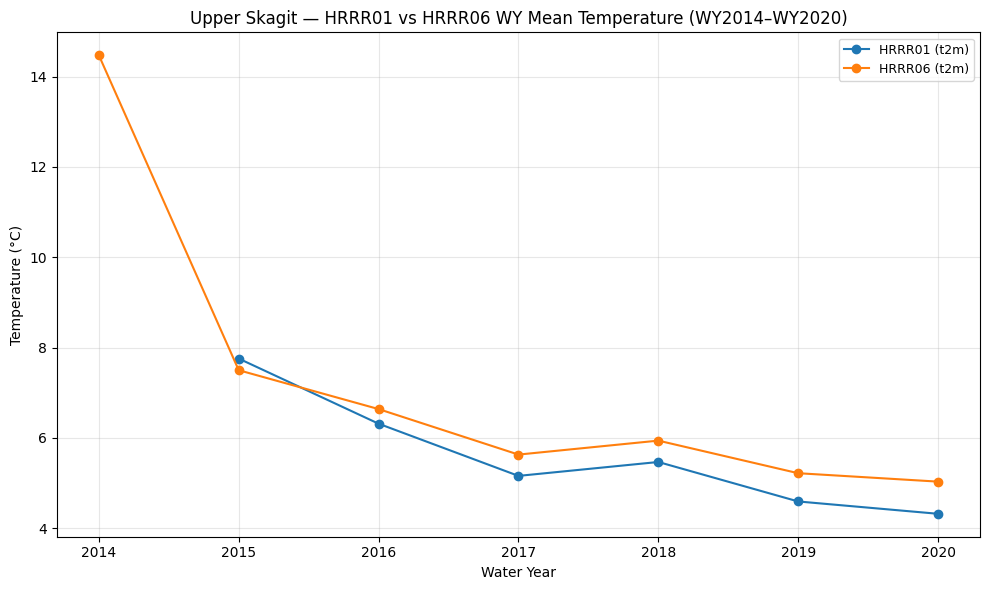

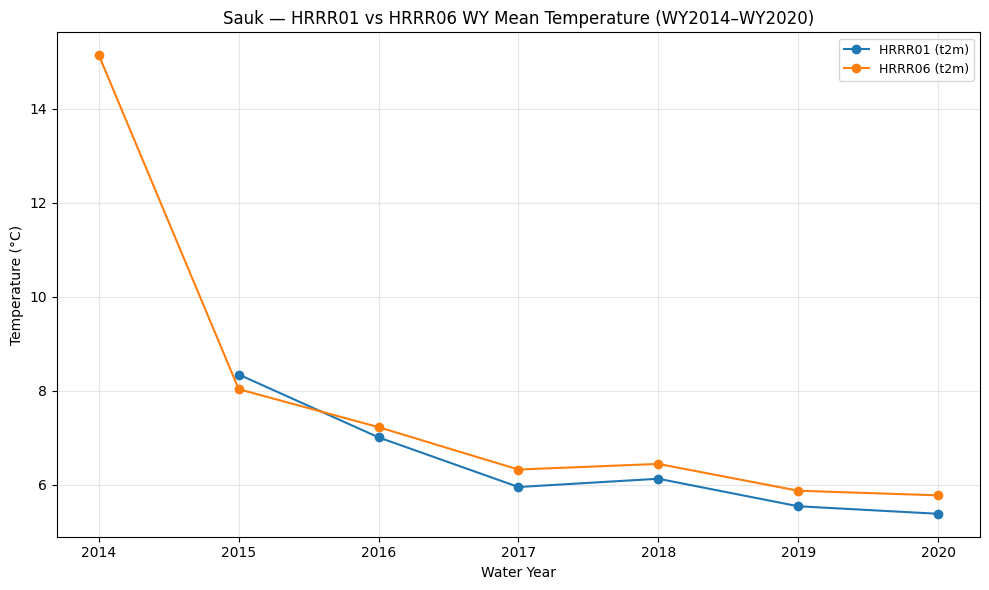

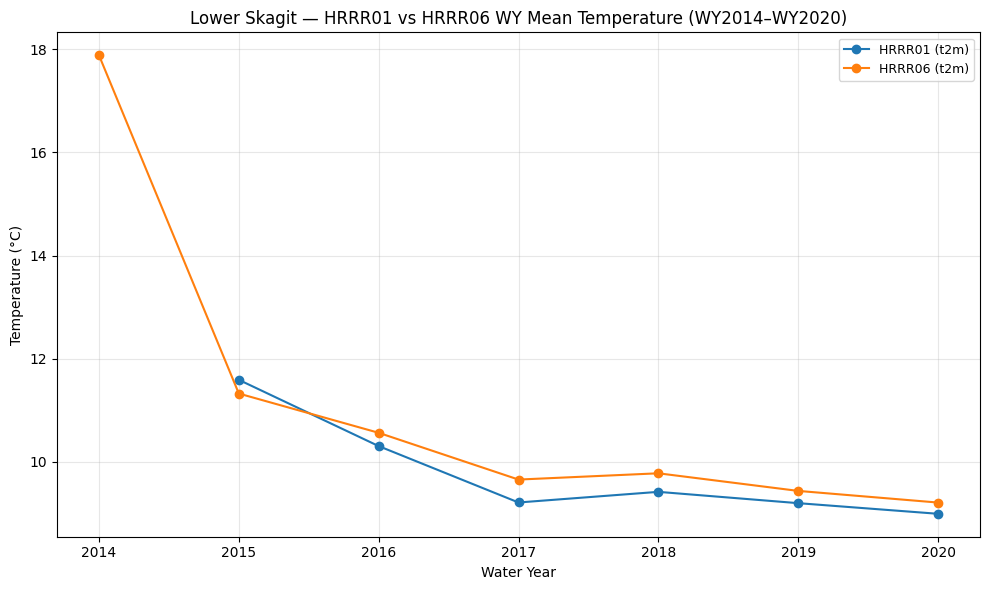

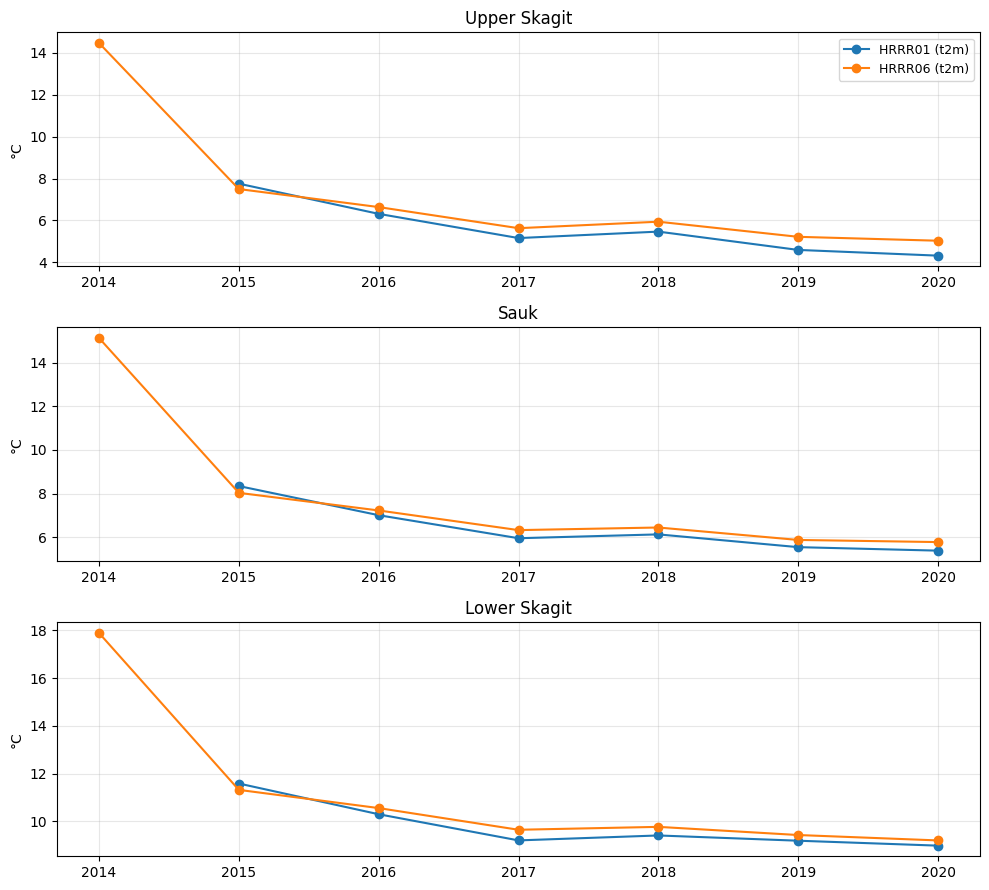

In [ ]:
# ==========================================================
# HRRR01 vs HRRR06 (WY Mean Temperature)
# Fixes:
# 1) water_year_index explicitly named "year" to avoid KeyError('year')
# 2) HRRR06 zarr filename pattern relaxed: any .zarr starting with YYYY-MM
# ==========================================================

import re, glob, time
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2020
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# HRRR dirs
P_HRRR01_DIR = BASE / "weather_data"
P_HRRR06_DIR = BASE / "weather_data_06"

# ---------------- Helpers----------------
def _ensure_time_name(obj):
    if isinstance(obj, xr.Dataset):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        if "time" not in obj.coords:
            for alt in ("day", "date"):
                if alt in obj.coords:
                    obj = obj.rename({alt: "time"}); break
        return obj
    if isinstance(obj, xr.DataArray):
        if "time" not in obj.dims:
            for alt in ("day", "date"):
                if alt in obj.dims:
                    obj = obj.rename({alt: "time"}); break
        return obj
    return obj

def ensure_time_sorted_unique(da):
    da = _ensure_time_name(da)
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_celsius(da):
    da = _ensure_time_name(da)
    try:
        probe = da.isel(time=0) if "time" in da.dims else da
        m = float(probe.mean().compute()) if hasattr(probe.data, "compute") else float(probe.mean())
    except Exception:
        m = 0.0
    return da - 273.15 if m > 150 else da

# FIX: explicitly name WY index "year"
def water_year_index(time_da):
    wy = xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)
    return wy.rename("year")

def water_year_mean_over_time(da):
    da = _ensure_time_name(da)
    wy = water_year_index(da["time"])  # named "year"
    out = da.groupby(wy).mean("time", skipna=True)

    # extra safety: force dim name to "year"
    if "year" not in out.dims:
        candidates = [d for d in out.dims if d not in ("time", "region")]
        if candidates:
            out = out.rename({candidates[0]: "year"})
        elif "group" in out.dims:
            out = out.rename({"group": "year"})
    return out

def pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars: return v
    cl = [c.lower() for c in candidates]
    for v in ds.data_vars:
        if v.lower() in cl: return v
    return None

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","lat2d","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","lon2d","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def _to_2d(arr):
    arr = _ensure_time_name(arr)
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","lon2d","lat2d","south_north","west_east")]
        if not extra: break
        arr = arr.isel({extra[0]: 0})
    return arr

def load_regions_gdf():
    import geopandas as gpd
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    return regions_gdf.sort_values("Name").reset_index(drop=True)

def region_mean(da, grid_ds, regions_gdf):
    import regionmask
    da = _ensure_time_name(da)
    grid_ds = _ensure_time_name(grid_ds)

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da.expand_dims(region=list(regions_gdf["Name"].values))

    lat_name, lon_name = find_lat_lon_names(grid_ds)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(grid_ds[lon_name])
    lat = _to_2d(grid_ds[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- HRRR ingest function (HRRR01 + HRRR06) ----------------
def ingest_hrrr_wy_mean_temp(hrrr_dir: Path, label: str):
    print(f"[{label}] Computing WY mean temp from monthly zarrs (t2m) in {hrrr_dir} ...")

    if not hrrr_dir.exists():
        print(f"[{label}] SKIP: dir missing: {hrrr_dir}")
        return []

    monthly = sorted(hrrr_dir.glob("*.zarr"))

    # FIX: accept any .zarr starting with YYYY-MM (works for weather_data_06 naming)
    monthly = [p for p in monthly if re.match(r"^\d{4}-\d{2}.*\.zarr$", p.name)]
    if not monthly:
        print(f"[{label}] SKIP: No monthly zarrs start with YYYY-MM in {hrrr_dir}")
        return []

    need_prefixes = set(pd.date_range(GLOBAL_START, GLOBAL_END, freq="MS").strftime("%Y-%m").tolist())
    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])
    if not parts:
        print(f"[{label}] SKIP: No overlapping months for window {GLOBAL_START}..{GLOBAL_END}")
        return []

    ds0 = xr.open_zarr(parts[0], consolidated=False)

    if "t2m" not in ds0:
        ds0.close()
        raise RuntimeError(f"[{label}] missing 't2m' in {parts[0].name}. Vars={list(ds0.data_vars)[:30]}")

    dsets = [xr.open_zarr(p, consolidated=False)[["t2m"]] for p in parts]
    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override")

    da = to_celsius(ensure_time_sorted_unique(ds["t2m"]))
    daily = da.resample(time="1D").mean()

    rm_daily = ensure_time_sorted_unique(
        region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
    ).sel(time=slice(GLOBAL_START, GLOBAL_END))

    wy = water_year_mean_over_time(rm_daily)

    out_rows = []
    for wy_i in range(YEAR_MIN, YEAR_MAX + 1):
        if "year" not in wy.dims and "year" not in wy.coords:
            # hard fail for debugging if xarray does something weird
            raise RuntimeError(f"[{label}] WY output missing 'year'. dims={wy.dims}, coords={list(wy.coords)}")
        if wy_i not in wy["year"].values:
            continue
        for r in wy["region"].values:
            val = float(wy.sel(year=wy_i, region=r).values)
            if np.isfinite(val):
                out_rows.append({"dataset": f"{label} (t2m)", "region": str(r), "year": int(wy_i), "temp_c": float(val)})

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds.close()
    except Exception: pass
    try: ds0.close()
    except Exception: pass

    print(f"[{label}] Done. rows={len(out_rows)}")
    return out_rows


# ==========================================================
# Run HRRR01 + HRRR06 and plot
# ==========================================================
regions_gdf = load_regions_gdf()
rows = []

# HRRR01
try:
    rows += ingest_hrrr_wy_mean_temp(P_HRRR01_DIR, "HRRR01")
except Exception as e:
    print("[HRRR01] SKIP/FAILED:", repr(e))

# HRRR06
try:
    rows += ingest_hrrr_wy_mean_temp(P_HRRR06_DIR, "HRRR06")
except Exception as e:
    print("[HRRR06] SKIP/FAILED:", repr(e))

df = (
    pd.DataFrame(rows)
      .groupby(["dataset","region","year"], as_index=False)
      .agg(temp_c=("temp_c","mean"))
      .sort_values(["region","dataset","year"])
      .reset_index(drop=True)
)

print("\n[FINAL] Datasets:", sorted(df["dataset"].unique().tolist()))
print(df.head(20))

# ==========================================================
# Plot: HRRR01 vs HRRR06 (per region)
# ==========================================================
if not df.empty:
    for region in REGION_NAMES:
        fig = plt.figure(figsize=(10, 6))
        ax = plt.gca()

        sub = df[df["region"] == region].copy()
        for dsname, g in sub.groupby("dataset"):
            g = g.sort_values("year")
            ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))

        ax.set_title(f"{region} — HRRR01 vs HRRR06 WY Mean Temperature (WY{YEAR_MIN}–WY{YEAR_MAX})")
        ax.set_xlabel("Water Year")
        ax.set_ylabel("Temperature (°C)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    fig = plt.figure(figsize=(10, 9))
    for i, region in enumerate(REGION_NAMES, start=1):
        ax = plt.subplot(3, 1, i)
        sub = df[df["region"] == region].copy()
        for dsname, g in sub.groupby("dataset"):
            g = g.sort_values("year")
            ax.plot(g["year"], g["temp_c"].astype(float), marker="o", label=str(dsname))
        ax.set_title(region)
        ax.set_ylabel("°C")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("[PLOT] df is empty (no HRRR rows). Check zarr names + t2m variable existence.")